# Bilişsel Performans Skoru Tahmini

Bu çalışmada uyku, stres, fiziksel aktivite, çalışma düzeni, ruh sağlığı ve yaşam tarzı değişkenleri kullanılarak bireylerin bilişsel performans skorları tahmin edilmiştir. Problem bir regresyon problemidir ve model başarısı RMSE metriği ile değerlendirilmiştir.


## 1. Problem Tanımı

Bu yarışmanın amacı, bireylere ait demografik bilgiler, uyku alışkanlıkları, stres düzeyi, fiziksel aktivite, çalışma düzeni ve ruh sağlığı gibi değişkenlerden yararlanarak `bilissel_performans_skoru` değerini tahmin etmektir.

Hedef değişken 0 ile 10 arasında yer alan sürekli bir skordur. Bu nedenle problem bir regresyon problemi olarak ele alınmıştır.

Yarışma metriği RMSE olduğu için model değerlendirmesinde temel metrik olarak Kök Ortalama Kare Hata kullanılmıştır.


## 2. Değerlendirme Metriği: RMSE

RMSE, tahmin edilen değerler ile gerçek değerler arasındaki farkların karelerinin ortalamasının kareköküdür.

Bu metrik büyük hataları daha fazla cezalandırır. Bu nedenle yalnızca ortalama olarak iyi tahmin yapmak değil, büyük sapmaları azaltmak da önemlidir.

Bu çalışmada tüm model karşılaştırmaları RMSE üzerinden yapılacaktır.


In [114]:
import pandas as pd

# Veri setlerini yukledik
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test_x.csv')

# Amacimiz orijinal veri setlerini koruyup kopyalar olusturmak
train_fe = train.copy()
test_fe = test.copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (56000, 24)
Test shape: (24000, 23)


## 3. Exploratory Data Analysis (EDA)

Bu bölümde yarışma tarafından verilen train ve test veri setleri incelenmiştir.

EDA aşamasında amaç, modelleme öncesinde verinin genel yapısını, eksik değerleri, hedef değişkenin dağılımını, sayısal ve kategorik değişkenlerin hedefle ilişkisini ve train-test dağılım uyumunu anlamaktır.


### 3.1 Veri Setinin Genel Yapısı

İlk olarak train ve test veri setlerinin boyutları, kolon yapıları ve hedef değişkenin train veri setindeki varlığı incelenmiştir.


In [99]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nTrain'de olup test'te olmayan kolonlar:")
print(sorted(set(train.columns) - set(test.columns)))

print("\nTest'te olup train'de olmayan kolonlar:")
print(sorted(set(test.columns) - set(train.columns)))


Train shape: (56000, 24)
Test shape: (24000, 23)

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Train'de olup test'te olmayan kolo

In [100]:
train.head()


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [101]:
test.head()


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


Train veri seti `56000` satır ve `24` kolondan oluşmaktadır. Test veri seti ise `24000` satır ve `23` kolondan oluşmaktadır.

Train ve test veri setleri arasındaki tek kolon farkı hedef değişken olan `bilissel_performans_skoru` kolonudur. Bu durum problemin bir gözetimli öğrenme problemi olduğunu göstermektedir.

Modelin amacı, train veri setindeki hedef değişkeni öğrenerek test veri setindeki bireyler için `bilissel_performans_skoru` tahmini üretmektir.


### 3.2 Eksik Değer Analizi

Bu bölümde train ve test veri setlerinde eksik değer bulunan kolonlar incelenmiştir.

Eksik değerlerin hangi değişkenlerde yoğunlaştığını görmek, modelleme ve feature engineering aşamalarında doğru strateji belirlemek açısından önemlidir.


In [102]:
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

missing_summary = pd.DataFrame({
    "train_missing": missing_train,
    "train_missing_pct": (missing_train / len(train) * 100).round(2),
    "test_missing": missing_test,
    "test_missing_pct": (missing_test / len(test) * 100).round(2)
})

missing_summary = missing_summary[
    (missing_summary["train_missing"] > 0) |
    (missing_summary["test_missing"] > 0)
].sort_values(by="train_missing", ascending=False)

missing_summary


,train_missing,train_missing_pct,test_missing,test_missing_pct
kronotip,1968,3.51,832.0,3.47
vucut_kitle_indeksi,1752,3.13,648.0,2.70
stres_skoru,1715,3.06,765.0,3.19
uyku_oncesi_kafein_mg,1463,2.61,697.0,2.90
meslek,1378,2.46,622.0,2.59
ruh_sagligi_durumu,1096,1.96,504.0,2.10


<Figure size 1000x500 with 0 Axes>

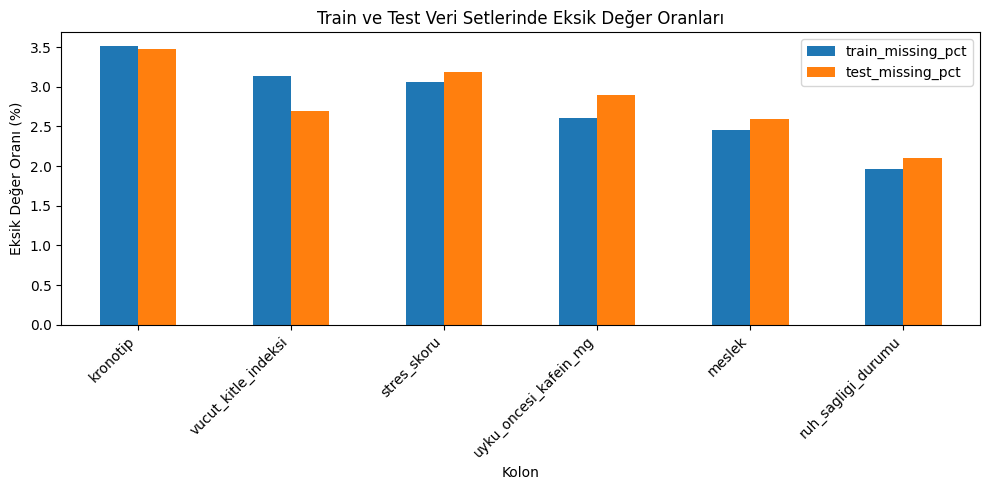

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))

missing_summary[["train_missing_pct", "test_missing_pct"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Train ve Test Veri Setlerinde Eksik Değer Oranları")
plt.ylabel("Eksik Değer Oranı (%)")
plt.xlabel("Kolon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Eksik değer analizi sonucunda eksik değerlerin yalnızca sınırlı sayıda kolonda bulunduğu görülmektedir.

Eksik değer içeren başlıca kolonlar `kronotip`, `vucut_kitle_indeksi`, `stres_skoru`, `uyku_oncesi_kafein_mg`, `meslek` ve `ruh_sagligi_durumu` değişkenleridir.

Train ve test veri setlerindeki eksik değer oranlarının birbirine yakın olması, iki veri setinin benzer dağılıma sahip olduğunu göstermektedir.

Bu eksik değerler modelleme aşamasında doğrudan silinmemiştir. Bunun yerine feature engineering aşamasında eksik değer göstergeleri oluşturularak eksikliğin kendisinin de model tarafından öğrenilebilmesi sağlanmıştır.


### 3.3 Hedef Değişken Analizi

Bu bölümde modelin tahmin etmeye çalıştığı hedef değişken olan `bilissel_performans_skoru` incelenmiştir.

Hedef değişkenin dağılımını anlamak, problemin yapısını ve modelin hangi aralıkta tahmin üretmesi gerektiğini görmek açısından önemlidir.


In [106]:
target = "bilissel_performans_skoru"

train[target].describe()


,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


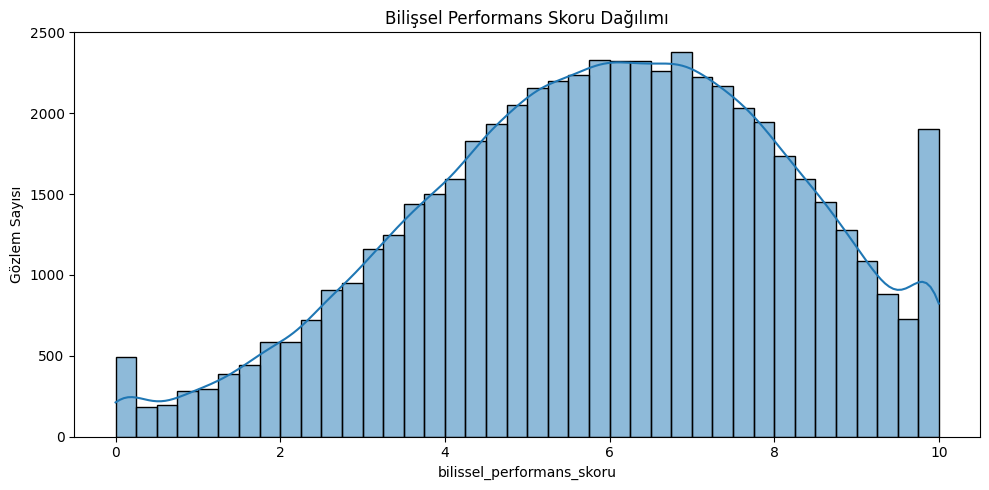

In [107]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train[target],
    bins=40,
    kde=True
)

plt.title("Bilişsel Performans Skoru Dağılımı")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Gözlem Sayısı")
plt.tight_layout()
plt.show()


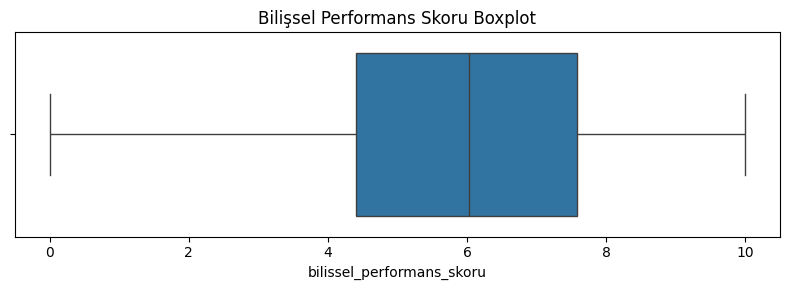

In [108]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=train[target])

plt.title("Bilişsel Performans Skoru Boxplot")
plt.xlabel("bilissel_performans_skoru")
plt.tight_layout()
plt.show()


In [109]:
print("Minimum skor:", train[target].min())
print("Maksimum skor:", train[target].max())

print("0 olan gözlem sayısı:", (train[target] == 0).sum())
print("10 olan gözlem sayısı:", (train[target] == 10).sum())

print("0 olan oran (%):", round((train[target] == 0).mean() * 100, 2))
print("10 olan oran (%):", round((train[target] == 10).mean() * 100, 2))


Minimum skor: 0.0
Maksimum skor: 10.0
0 olan gözlem sayısı: 191
10 olan gözlem sayısı: 789
0 olan oran (%): 0.34
10 olan oran (%): 1.41


Hedef değişken olan `bilissel_performans_skoru` 0 ile 10 arasında değer almaktadır. Bu nedenle problem sürekli bir hedef değişkenin tahmin edildiği regresyon problemi olarak ele alınmıştır.

Dağılım incelendiğinde skorların orta ve yüksek değerlere doğru yoğunlaştığı, ancak tüm 0-10 aralığına yayıldığı görülmektedir.

Hedef değişkende 0 ve 10 sınır değerlerinde gözlemler bulunmaktadır. Bu durum, final tahminlerin 0-10 aralığında sınırlandırılmasının mantıklı olabileceğini göstermektedir.

Bu nedenle final submission aşamasında model tahminleri `np.clip` ile 0 ve 10 aralığına çekilmiştir.


### 3.4 Sayısal Değişkenlerin Hedefle İlişkisi

Bu bölümde sayısal değişkenlerin `bilissel_performans_skoru` ile ilişkisi incelenmiştir.

İlk olarak sayısal değişkenler ile hedef değişken arasındaki Pearson korelasyon katsayıları hesaplanmıştır. Bu analiz, hangi sayısal değişkenlerin hedefle daha güçlü doğrusal ilişkiye sahip olduğunu görmek için kullanılmıştır.


In [110]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# id hedefle anlamlı bir değişken olmadığı için korelasyon analizinden çıkarıyoruz
numeric_cols_for_corr = [
    col for col in numeric_cols
    if col not in ["id", target]
]

corr_with_target = train[numeric_cols_for_corr + [target]].corr()[target]
corr_with_target = corr_with_target.drop(target).sort_values()

corr_with_target


,bilissel_performans_skoru
stres_skoru,-0.586676
gunluk_calisma_saati,-0.342112
gecelik_uyanma_sayisi,-0.270349
uykuya_dalma_suresi_dk,-0.207349
dinlenik_nabiz_bpm,-0.089389
yas,-0.070659
uyku_oncesi_kafein_mg,-0.062387
uyku_oncesi_ekran_suresi_dk,-0.044631
vucut_kitle_indeksi,-0.037990
sekerleme_suresi_dk,-0.023683


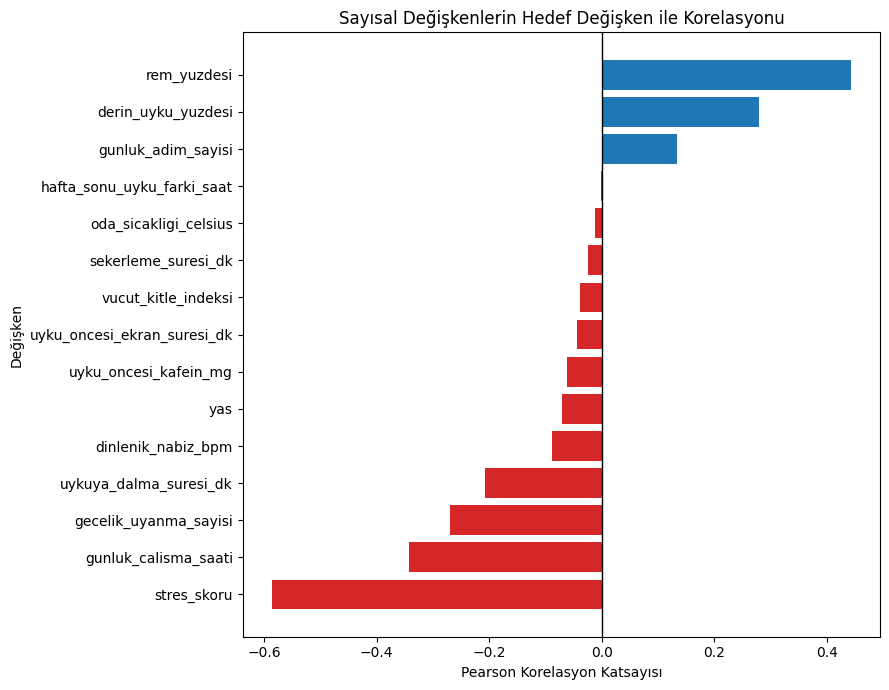

In [111]:
plt.figure(figsize=(9, 7))

colors = ["#d62728" if val < 0 else "#1f77b4" for val in corr_with_target.values]

plt.barh(
    corr_with_target.index,
    corr_with_target.values,
    color=colors
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Sayısal Değişkenlerin Hedef Değişken ile Korelasyonu")
plt.xlabel("Pearson Korelasyon Katsayısı")
plt.ylabel("Değişken")
plt.tight_layout()
plt.show()


Korelasyon analizi sonucunda hedef değişkenle en güçlü ilişkili sayısal değişkenlerin stres, uyku mimarisi, çalışma süresi ve uyku bölünmesiyle ilgili olduğu görülmektedir.

`stres_skoru` hedef değişkenle en güçlü negatif ilişkiye sahip değişkendir. Bu durum stres düzeyi arttıkça bilişsel performans skorunun düşme eğiliminde olduğunu göstermektedir.

`rem_yuzdesi` ve `derin_uyku_yuzdesi` hedef değişkenle pozitif ilişkilidir. Bu sonuç, uyku mimarisinin bilişsel performans açısından önemli bir sinyal taşıdığını göstermektedir.

`gunluk_calisma_saati`, `gecelik_uyanma_sayisi` ve `uykuya_dalma_suresi_dk` değişkenleri hedefle negatif ilişkilidir. Bu durum uzun çalışma süresi, sık uyanma ve uykuya geç dalmanın bilişsel performansı olumsuz etkileyebileceğini göstermektedir.

Bu bulgular, feature engineering ve modelleme aşamalarında stres, uyku kalitesi ve çalışma yükü değişkenlerine özellikle dikkat edilmesi gerektiğini göstermektedir.


### 3.5 Kategorik Değişkenlerin Hedefle İlişkisi

Bu bölümde kategorik değişkenlere göre `bilissel_performans_skoru` ortalamaları incelenmiştir.

Kategorik değişkenlerin hedef değişkenle ilişkisini anlamak, modelleme aşamasında bu değişkenlerin önemini değerlendirmek açısından faydalıdır.


In [112]:
categorical_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

categorical_cols


['cinsiyet',
 'meslek',
 'ulke',
 'kronotip',
 'ruh_sagligi_durumu',
 'mevsim',
 'gun_tipi']

In [113]:
for col in categorical_cols:
    print(f"\n{col}")
    display(
        train.groupby(col, dropna=False)[target]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
        .round(3)
    )



cinsiyet


,count,mean,median,std
cinsiyet,,,,
Erkek,27324,5.914,6.030,2.225
Kadin,28676,5.912,6.035,2.239



meslek


,count,mean,median,std
meslek,,,,
Emekli,3778,7.935,8.140,1.609
Ev Hanimi,3224,7.056,7.235,1.803
Serbest Calisan,3812,6.986,7.200,1.871
Egitimci,4395,6.344,6.507,2.011
Muhendis,6533,6.223,6.327,2.041
NaN,1378,6.023,6.141,2.309
Satis ve Pazarlama Calisani,3899,6.010,6.148,2.055
Yonetici,4454,5.730,5.781,2.128
Ogrenci,8132,5.535,5.602,2.111



ulke


...

,count,mean,median,std
ruh_sagligi_durumu,,,,
Saglikli,38365,6.492,6.622,2.018
NaN,1096,5.939,6.057,2.185
Anksiyete,8270,5.012,5.093,2.098
Depresyon,5504,4.394,4.509,2.012
Anksiyete ve depresyon,2765,3.590,3.614,2.047



mevsim


,count,mean,median,std
mevsim,,,,
Sonbahar-Kis,27857,5.916,6.027,2.226
Ilkbahar-Yaz,28143,5.910,6.041,2.238



gun_tipi


,count,mean,median,std
gun_tipi,,,,
Hafta sonu,15948,6.993,7.216,1.938
Hafta ici,40052,5.483,5.542,2.195


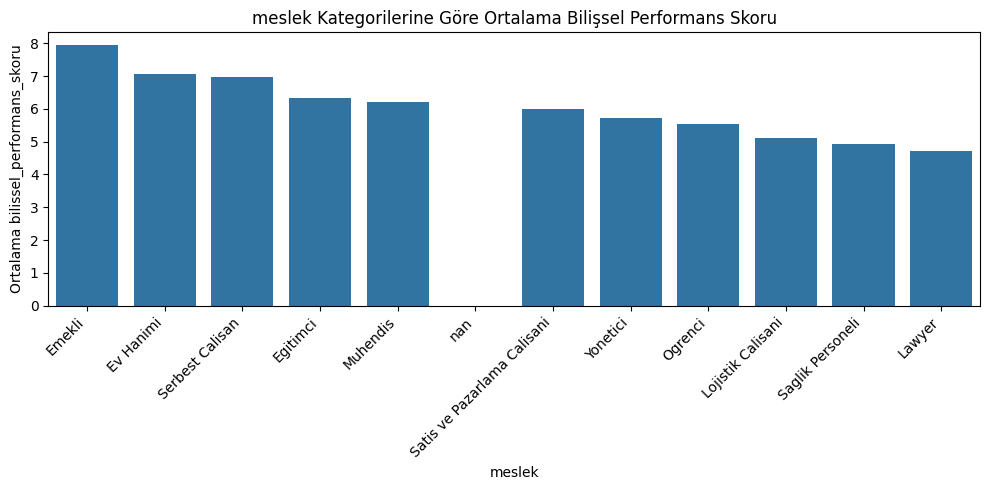

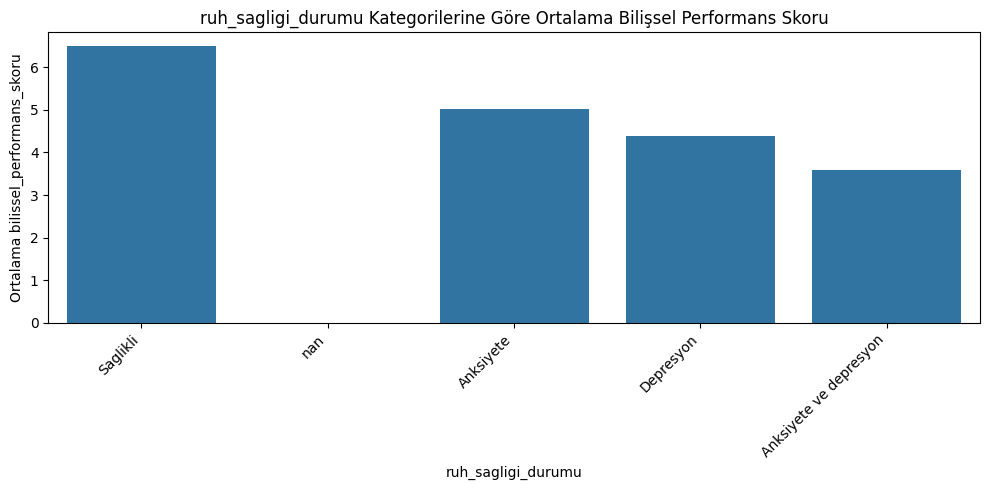

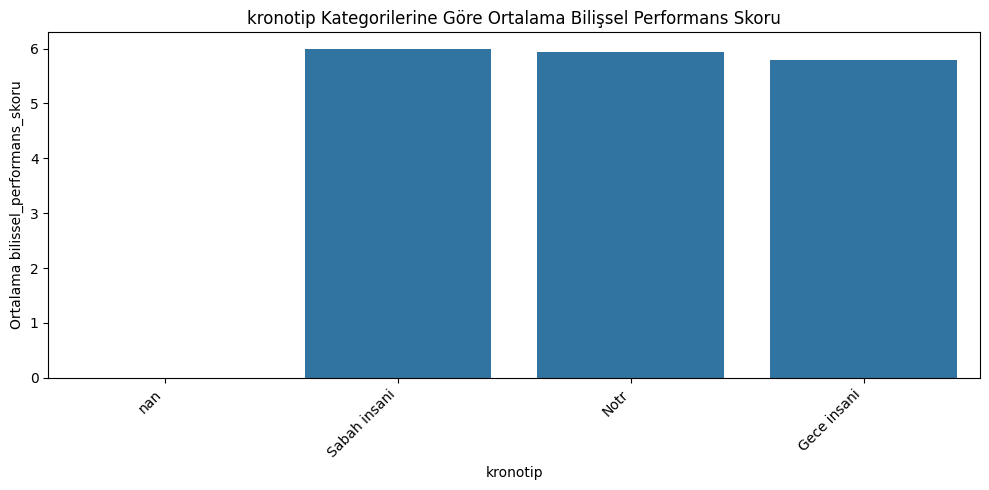

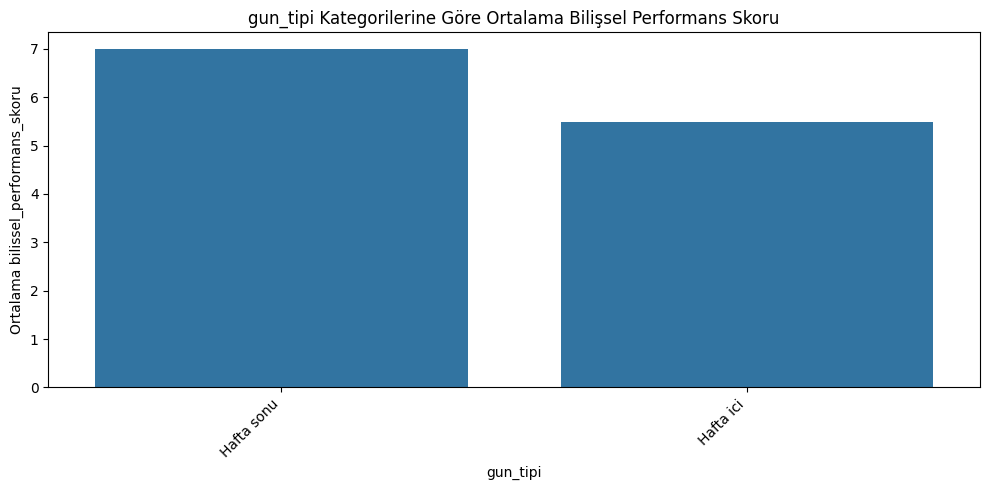

In [115]:
important_cat_cols = [
    "meslek",
    "ruh_sagligi_durumu",
    "kronotip",
    "gun_tipi"
]

for col in important_cat_cols:
    plt.figure(figsize=(10, 5))

    order = (
        train.groupby(col, dropna=False)[target]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    sns.barplot(
        data=train,
        x=col,
        y=target,
        order=order,
        estimator=np.mean,
        errorbar=None
    )

    plt.title(f"{col} Kategorilerine Göre Ortalama Bilişsel Performans Skoru")
    plt.xlabel(col)
    plt.ylabel("Ortalama bilissel_performans_skoru")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Kategorik değişkenler incelendiğinde bazı değişkenlerin hedef skor üzerinde belirgin ayrışmalar oluşturduğu görülmektedir.

`ruh_sagligi_durumu` değişkeni hedef değişkenle güçlü bir ilişki göstermektedir. Sağlıklı bireylerin ortalama bilişsel performans skoru daha yüksekken, depresyon veya anksiyete ve depresyon kategorilerindeki bireylerde ortalama skor daha düşüktür.

`gun_tipi` değişkeni de belirgin bir fark oluşturmaktadır. Hafta sonu gözlemlerinde ortalama bilişsel performans skorunun hafta içine göre daha yüksek olduğu görülmektedir.

`meslek` değişkeninde de kategoriler arasında anlamlı farklılıklar bulunmaktadır. Bazı meslek gruplarında ortalama skor daha yüksekken, yoğun stres ve çalışma yüküyle ilişkili olabilecek mesleklerde skor daha düşük görünmektedir.

Bu bulgular kategorik değişkenlerin modelleme aşamasında önemli sinyaller taşıyabileceğini göstermektedir. Bu nedenle CatBoost gibi kategorik değişkenleri güçlü şekilde işleyebilen modeller bu problem için uygun görülmüştür.


### 3.6 Train-Test Dağılım Karşılaştırması

Bu bölümde train ve test veri setlerindeki değişken dağılımlarının birbirine benzer olup olmadığı incelenmiştir.

Train ve test dağılımlarının benzer olması, cross validation sonuçlarının test veri setindeki performansı daha güvenilir temsil etmesi açısından önemlidir.


In [116]:
common_numeric_cols = [
    col for col in test.select_dtypes(include=[np.number]).columns
    if col in train.columns and col != "id"
]

numeric_distribution_comparison = []

for col in common_numeric_cols:
    train_mean = train[col].mean()
    test_mean = test[col].mean()
    train_std = train[col].std()

    standardized_diff = (
        (test_mean - train_mean) / train_std
        if train_std != 0 else 0
    )

    numeric_distribution_comparison.append({
        "column": col,
        "train_mean": train_mean,
        "test_mean": test_mean,
        "standardized_mean_diff": standardized_diff,
        "train_missing_pct": train[col].isnull().mean() * 100,
        "test_missing_pct": test[col].isnull().mean() * 100
    })

numeric_distribution_comparison = pd.DataFrame(
    numeric_distribution_comparison
).sort_values(
    "standardized_mean_diff",
    key=lambda x: x.abs(),
    ascending=False
)

numeric_distribution_comparison.round(4)


,column,train_mean,test_mean,standardized_mean_diff,train_missing_pct,test_missing_pct
1,vucut_kitle_indeksi,26.2737,26.3545,0.0180,3.1286,2.7000
2,rem_yuzdesi,20.2335,20.2782,0.0130,0.0000,0.0000
12,dinlenik_nabiz_bpm,66.6032,66.5152,-0.0120,0.0000,0.0000
10,stres_skoru,5.7414,5.7238,-0.0108,3.0625,3.1875
3,derin_uyku_yuzdesi,20.2461,20.2924,0.0108,0.0000,0.0000
11,gunluk_calisma_saati,7.1565,7.1233,-0.0096,0.0000,0.0000
8,gunluk_adim_sayisi,7493.1976,7516.7629,0.0068,0.0000,0.0000
4,uykuya_dalma_suresi_dk,20.1075,20.0638,-0.0054,0.0000,0.0000
9,sekerleme_suresi_dk,15.4329,15.3227,-0.0052,0.0000,0.0000
0,yas,34.7144,34.6621,-0.0047,0.0000,0.0000


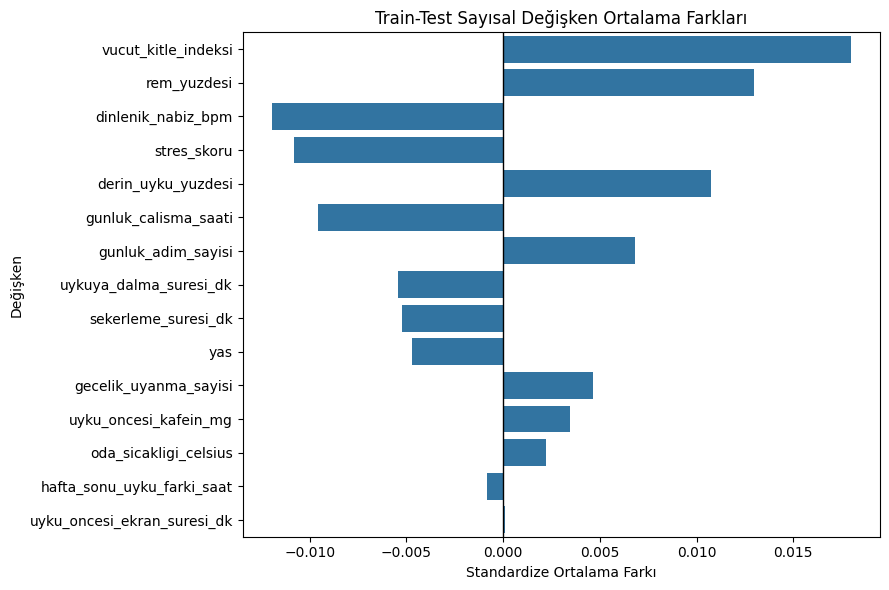

In [117]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=numeric_distribution_comparison,
    x="standardized_mean_diff",
    y="column"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Train-Test Sayısal Değişken Ortalama Farkları")
plt.xlabel("Standardize Ortalama Farkı")
plt.ylabel("Değişken")
plt.tight_layout()
plt.show()


In [118]:
categorical_distribution_diffs = []

for col in categorical_cols:
    train_dist = train[col].value_counts(normalize=True, dropna=False)
    test_dist = test[col].value_counts(normalize=True, dropna=False)

    all_categories = train_dist.index.union(test_dist.index)

    max_diff = (
        train_dist.reindex(all_categories, fill_value=0) -
        test_dist.reindex(all_categories, fill_value=0)
    ).abs().max()

    categorical_distribution_diffs.append({
        "column": col,
        "max_category_pct_diff": max_diff * 100,
        "train_unique": train[col].nunique(dropna=False),
        "test_unique": test[col].nunique(dropna=False)
    })

categorical_distribution_diffs = pd.DataFrame(
    categorical_distribution_diffs
).sort_values("max_category_pct_diff", ascending=False)

categorical_distribution_diffs.round(3)


,column,max_category_pct_diff,train_unique,test_unique
2,ulke,0.513,15,15
1,meslek,0.434,12,12
3,kronotip,0.406,4,4
4,ruh_sagligi_durumu,0.312,5,5
6,gun_tipi,0.221,2,2
0,cinsiyet,0.128,2,2
5,mevsim,0.032,2,2


Train-test dağılım karşılaştırması sonucunda sayısal değişkenlerin ortalamalarının train ve test veri setlerinde oldukça benzer olduğu görülmektedir.

Standardize ortalama farklarının düşük olması, test veri setinin train veri setinden belirgin şekilde farklılaşmadığını göstermektedir.

Kategorik değişkenlerde de train ve test veri setleri arasında ciddi bir dağılım farkı bulunmamaktadır. Kategori sayıları ve kategori oranları genel olarak uyumludur.

Bu sonuçlar, cross validation performansının test veri setindeki performansı temsil etme açısından güvenilir olabileceğini göstermektedir.


### 3.7 EDA Genel Bulgular

EDA aşamasında train ve test veri setlerinin genel yapısı, eksik değerleri, hedef değişken dağılımı, sayısal ve kategorik değişkenlerin hedefle ilişkisi ve train-test dağılım uyumu incelenmiştir.

Bu analizlerden elde edilen temel bulgular şunlardır:

- Problem, `bilissel_performans_skoru` hedef değişkeninin tahmin edildiği bir regresyon problemidir.
- Hedef değişken 0 ile 10 arasında değer almaktadır.
- Train ve test veri setleri kolon yapısı açısından uyumludur; aralarındaki tek fark hedef değişkenin yalnızca train veri setinde bulunmasıdır.
- Eksik değerler sınırlı sayıdaki kolonda yoğunlaşmaktadır.
- Train ve test veri setlerinde eksik değer oranları birbirine yakındır.
- Sayısal değişkenler içinde hedef değişkenle en güçlü ilişkiler stres, REM yüzdesi, derin uyku yüzdesi, çalışma saati ve uyku bölünmesiyle ilgili değişkenlerde görülmektedir.
- `stres_skoru`, `gunluk_calisma_saati`, `gecelik_uyanma_sayisi` ve `uykuya_dalma_suresi_dk` değişkenleri hedefle negatif ilişkilidir.
- `rem_yuzdesi`, `derin_uyku_yuzdesi` ve `gunluk_adim_sayisi` değişkenleri hedefle pozitif ilişkilidir.
- Kategorik değişkenler içinde `ruh_sagligi_durumu`, `gun_tipi` ve `meslek` değişkenleri hedef skor açısından belirgin farklılıklar göstermektedir.
- Train ve test veri setleri arasında belirgin bir dağılım kayması gözlenmemiştir.

Bu bulgular doğrultusunda feature engineering aşamasında eksik değer göstergeleri, kategori kombinasyonları, frequency encoding ve grup bazlı istatistiksel özellikler oluşturulmuştur.

Modelleme aşamasında ise kategorik değişkenleri güçlü şekilde işleyebilen CatBoost modeli ana model olarak değerlendirilmiştir.


## 4. Feature Engineering


### 4.1 Uyku Mimarisinden Türetilen Değişkenler

1.   Liste öğesi
2.   Liste öğesi



REM uykusu ve derin uyku, öğrenme, hafıza konsolidasyonu ve zihinsel toparlanma süreçleriyle ilişkili önemli uyku bileşenleridir.

Bu nedenle `rem_yuzdesi` ve `derin_uyku_yuzdesi` değişkenleri birlikte değerlendirilerek uykunun restoratif yapısını temsil eden yeni değişkenler oluşturulmuştur.

Bu bölümde türetilen değişkenler:

- `restoratif_uyku_orani`: REM ve derin uyku yüzdelerinin toplamı
- `hafif_uyku_tahmini`: REM ve derin uyku dışındaki uyku oranı
- `rem_derin_dengesi`: REM uykusunun derin uykuya oranı
- `rem_derin_farki`: REM ve derin uyku yüzdeleri arasındaki mutlak fark


In [18]:
def add_sleep_architecture_features(df):
    df = df.copy()

    df["restoratif_uyku_orani"] = df["rem_yuzdesi"] + df["derin_uyku_yuzdesi"]
    df["hafif_uyku_tahmini"] = 100 - df["restoratif_uyku_orani"]
    df["rem_derin_dengesi"] = df["rem_yuzdesi"] / (df["derin_uyku_yuzdesi"] + 1e-6)
    df["rem_derin_farki"] = (df["rem_yuzdesi"] - df["derin_uyku_yuzdesi"]).abs()

    return df

train_fe = add_sleep_architecture_features(train_fe)
test_fe = add_sleep_architecture_features(test_fe)

sleep_architecture_cols = [
    "rem_yuzdesi",
    "derin_uyku_yuzdesi",
    "restoratif_uyku_orani",
    "hafif_uyku_tahmini",
    "rem_derin_dengesi",
    "rem_derin_farki"
]

train_fe[sleep_architecture_cols].head()


,rem_yuzdesi,derin_uyku_yuzdesi,restoratif_uyku_orani,hafif_uyku_tahmini,rem_derin_dengesi,rem_derin_farki
0,14.431210,14.645436,29.076646,70.923354,0.985372,0.214226
1,21.771870,27.220360,48.992230,51.007770,0.799838,5.448491
2,18.178857,25.530104,43.708961,56.291039,0.712056,7.351246
3,21.438151,15.891188,37.329339,62.670661,1.349059,5.546964
4,25.468018,16.356738,41.824756,58.175244,1.557035,9.111280


#### Uyku Mimarisi Değişkenlerinin Kontrolü

Bu adımda, uyku mimarisinden türetilen yeni değişkenlerin mantıklı aralıklarda oluşup oluşmadığı kontrol edilmiştir.

`describe().T` kullanılarak seçilen değişkenler için temel özet istatistikler incelenmiştir. Bu tablo; değişkenlerin gözlem sayısı, ortalaması, standart sapması, minimum ve maksimum değerleri ile çeyreklik değerlerini göstermektedir.

Bu kontrol sayesinde özellikle aşağıdaki noktalar değerlendirilmiştir:

- Yeni oluşturulan değişkenlerde eksik veya hatalı değer oluşup oluşmadığı
- `restoratif_uyku_orani` değerinin beklenen aralıkta olup olmadığı
- `hafif_uyku_tahmini` değerinin negatif gibi mantıksız bir değer alıp almadığı
- `rem_derin_dengesi` oranında aşırı uç değerler oluşup oluşmadığı
- Feature engineering adımının veri üzerinde doğru şekilde çalışıp çalışmadığı

Bu tür kontroller, modelleme aşamasına geçmeden önce türetilen değişkenlerin güvenilirliğini değerlendirmek için önemlidir.


In [19]:
train_fe[sleep_architecture_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
rem_yuzdesi,56000.0,20.233500,3.442993,10.000000,17.951724,20.302218,22.598180,30.000000
derin_uyku_yuzdesi,56000.0,20.246063,4.300421,5.000000,17.337866,20.292151,23.227117,30.000000
restoratif_uyku_orani,56000.0,40.479564,5.817557,16.987084,36.600833,40.538926,44.500611,60.000000
hafif_uyku_tahmini,56000.0,59.520436,5.817557,40.000000,55.499389,59.461074,63.399167,83.012916
rem_derin_dengesi,56000.0,1.048751,0.312106,0.337654,0.842373,0.997542,1.192266,4.925385
rem_derin_farki,56000.0,4.141605,3.114263,0.000000,1.642307,3.502877,6.003133,20.624082


#### Uyku Mimarisi Kontrol Tablosu Yorumu

Uyku mimarisi değişkenleri incelendiğinde türetilen değerlerin genel olarak mantıklı aralıklarda olduğu görülmektedir.

`restoratif_uyku_orani` değişkeni REM ve derin uyku yüzdelerinin toplamını göstermektedir. Ortalama değeri yaklaşık `%40.48` olarak hesaplanmıştır. Minimum değerin `%16.99`, maksimum değerin ise `%60.00` olması, bu değişkenin beklenen sınırlar içinde kaldığını göstermektedir.

`hafif_uyku_tahmini` değişkeni, REM ve derin uyku dışında kalan uyku oranını temsil etmektedir. Ortalama değeri yaklaşık `%59.52`'dir. Minimum değerin `%40.00`, maksimum değerin ise yaklaşık `%83.01` olması bu değişkende negatif veya mantıksız bir değer oluşmadığını göstermektedir.

`rem_derin_dengesi` değişkeninin ortalaması yaklaşık `1.05`'tir. Medyan değerinin `1.00`'a yakın olması, REM ve derin uyku yüzdelerinin veri setinde genel olarak dengeli dağıldığını göstermektedir. Maksimum değerin `4.93` olması bazı bireylerde REM yüzdesinin derin uykuya göre belirgin şekilde yüksek olduğunu göstermektedir; ancak bu değer veri aralığı açısından kabul edilebilir görünmektedir.

`rem_derin_farki` değişkeni REM ve derin uyku yüzdeleri arasındaki mutlak farkı göstermektedir. Ortalama fark yaklaşık `4.14` puandır. Bu değişken, uyku mimarisindeki dengesizliği temsil edebileceği için model açısından faydalı olabilir.

Genel olarak bu kontrol sonucunda uyku mimarisiyle ilgili üretilen değişkenlerde negatif, eksik veya mantıksız değer oluşmadığı görülmüştür. Bu nedenle bu değişkenler modelleme aşamasında kullanılabilir.


### 4.2 Uyku Bölünmesi ve Uyku Kalitesi

Uyku kalitesi yalnızca REM ve derin uyku yüzdeleriyle açıklanamaz. Uykuya dalma süresinin uzaması ve gece boyunca sık uyanma, uykunun toparlayıcı etkisini azaltabilir.

Bu nedenle bu bölümde uykuya dalma süresi ve gecelik uyanma sayısı birlikte değerlendirilerek uyku bölünmesini ve uyku kalitesini temsil eden yeni değişkenler oluşturulmuştur.

Türetilen değişkenler:

- `uyku_bozulma_skoru`: uykuya dalma süresi ve gece uyanma sayısını birlikte temsil eden birleşik skor
- `restoratif_uyku_bolunmus`: restoratif uyku oranının gece uyanma sayısına göre düzeltilmiş hali
- `gec_uykuya_dalma_flag`: uykuya dalma süresinin 30 dakikadan uzun olup olmadığını gösterir
- `cok_uyanma_flag`: gece uyanma sayısının 5 veya daha fazla olup olmadığını gösterir


In [20]:
def add_sleep_fragmentation_features(df):
    df = df.copy()

    df["uyku_bozulma_skoru"] = (
        df["uykuya_dalma_suresi_dk"] +
        df["gecelik_uyanma_sayisi"] * 10
    )

    df["restoratif_uyku_bolunmus"] = (
        df["restoratif_uyku_orani"] /
        (1 + df["gecelik_uyanma_sayisi"])
    )

    df["gec_uykuya_dalma_flag"] = (
        df["uykuya_dalma_suresi_dk"] > 30
    ).astype(int)

    df["cok_uyanma_flag"] = (
        df["gecelik_uyanma_sayisi"] >= 5
    ).astype(int)

    return df

train_fe = add_sleep_fragmentation_features(train_fe)
test_fe = add_sleep_fragmentation_features(test_fe)

sleep_fragmentation_cols = [
    "uykuya_dalma_suresi_dk",
    "gecelik_uyanma_sayisi",
    "uyku_bozulma_skoru",
    "restoratif_uyku_bolunmus",
    "gec_uykuya_dalma_flag",
    "cok_uyanma_flag"
]

train_fe[sleep_fragmentation_cols].head()


,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_bozulma_skoru,restoratif_uyku_bolunmus,gec_uykuya_dalma_flag,cok_uyanma_flag
0,27,7,97,3.634581,0,1
1,20,4,60,9.798446,0,0
2,33,7,103,5.463620,1,1
3,21,2,41,12.443113,0,0
4,21,8,101,4.647195,0,1


#### Uyku Bölünmesi Değişkenlerinin Kontrolü

Bu adımda, uyku bölünmesi ve uyku kalitesiyle ilgili türetilen değişkenlerin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

`describe().T` kullanılarak hem orijinal değişkenlerin hem de yeni oluşturulan değişkenlerin temel özet istatistikleri incelenmiştir.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `uyku_bozulma_skoru` değişkeninin beklenen aralıkta olup olmadığı
- `restoratif_uyku_bolunmus` değişkeninde negatif veya mantıksız değer oluşup oluşmadığı
- `gec_uykuya_dalma_flag` değişkeninin 0 ve 1 değerlerinden oluşup oluşmadığı
- `cok_uyanma_flag` değişkeninin 0 ve 1 değerlerinden oluşup oluşmadığı
- Uykuya dalma süresi ve gece uyanma sayısına bağlı olarak üretilen yeni değişkenlerin veri setine doğru şekilde eklenip eklenmediği

Bu tür kontroller, feature engineering adımlarının güvenilir şekilde ilerlediğini doğrulamak için önemlidir.


In [21]:
print("train shape:", train.shape)
print("train_fe shape:", train_fe.shape)
print("test shape:", test.shape)
print("test_fe shape:", test_fe.shape)


train shape: (56000, 24)
train_fe shape: (56000, 32)
test shape: (24000, 23)
test_fe shape: (24000, 31)


In [22]:
train_fe[sleep_fragmentation_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
uykuya_dalma_suresi_dk,56000.0,20.107536,8.063278,1.000000,14.000000,20.000000,25.000000,58.000000
gecelik_uyanma_sayisi,56000.0,3.344929,2.034618,0.000000,2.000000,3.000000,5.000000,8.000000
uyku_bozulma_skoru,56000.0,53.556821,22.100880,1.000000,37.000000,52.000000,68.000000,138.000000
restoratif_uyku_bolunmus,56000.0,12.787513,9.506002,2.058696,6.916981,9.701666,14.546216,59.532103
gec_uykuya_dalma_flag,56000.0,0.101125,0.301497,0.000000,0.000000,0.000000,0.000000,1.000000
cok_uyanma_flag,56000.0,0.276268,0.447155,0.000000,0.000000,0.000000,1.000000,1.000000


#### Uyku Bölünmesi Kontrol Tablosu Yorumu

Uyku bölünmesiyle ilgili değişkenler incelendiğinde yeni oluşturulan değerlerin genel olarak beklenen aralıklarda olduğu görülmektedir.

`uykuya_dalma_suresi_dk` değişkeninin ortalaması yaklaşık `20.11` dakikadır. Maksimum değerin `58` dakika olması bazı bireylerde uykuya dalma süresinin belirgin şekilde uzadığını göstermektedir.

`gecelik_uyanma_sayisi` değişkeninin ortalaması yaklaşık `3.34` olarak hesaplanmıştır. Maksimum değerin `8` olması veri setinde gece boyunca sık uyanan bireylerin bulunduğunu göstermektedir.

Bu iki değişkenden türetilen `uyku_bozulma_skoru` değişkeninin ortalaması yaklaşık `53.56`'dır. Minimum değerin `1`, maksimum değerin ise `138` olması, uyku bozulma skorunun bireyler arasında anlamlı farklılık gösterdiğini göstermektedir. Bu değişken, uykuya dalma süresi ile gece uyanma sayısını tek bir birleşik uyku kalitesi göstergesi olarak temsil etmektedir.

`restoratif_uyku_bolunmus` değişkeninin ortalaması yaklaşık `12.79`'dur. Bu değişken, restoratif uyku oranını gece uyanma sayısına göre düzelttiği için, uykunun hem yapısını hem de bölünme düzeyini birlikte değerlendirmektedir.

`gec_uykuya_dalma_flag` değişkeninin ortalaması yaklaşık `0.10`'dur. Bu durum bireylerin yaklaşık `%10`'unda uykuya dalma süresinin 30 dakikadan uzun olduğunu göstermektedir.

`cok_uyanma_flag` değişkeninin ortalaması yaklaşık `0.28`'dir. Buna göre bireylerin yaklaşık `%28`'inde gece uyanma sayısı 5 veya daha fazladır.

Genel olarak bu kontrol sonucunda uyku bölünmesi ve uyku kalitesiyle ilgili türetilen değişkenlerde mantıksız, negatif veya beklenmeyen bir değer oluşmadığı görülmektedir. Bu değişkenler modelleme aşamasında kullanılabilir.


### 4.3 Uyku Öncesi Uyarıcı Yükü

Uyku öncesi davranışlar, uyku kalitesi ve dolaylı olarak bilişsel performans üzerinde etkili olabilir. Özellikle kafein tüketimi ve uzun ekran süresi, uykuya dalma süresini ve uykunun toparlayıcı etkisini olumsuz etkileyebilecek faktörlerdir.

Bu nedenle bu bölümde `uyku_oncesi_kafein_mg` ve `uyku_oncesi_ekran_suresi_dk` değişkenleri birlikte değerlendirilerek uyku öncesi uyarıcı yükünü temsil eden yeni değişkenler oluşturulmuştur.

Türetilen değişkenler:

- `uyku_oncesi_uyarici_yuk`: kafein ve ekran süresinin logaritmik birleşimi
- `kafein_ekran_etkilesim`: kafein ve ekran süresinin çarpımı
- `kafein_var_mi`: uyku öncesi kafein tüketilip tüketilmediğini gösterir
- `yuksek_ekran_flag`: ekran süresinin yüksek olup olmadığını gösterir


In [23]:
import numpy as np

def add_pre_sleep_stimulation_features(df):
    df = df.copy()

    caffeine = df["uyku_oncesi_kafein_mg"].fillna(0)
    screen = df["uyku_oncesi_ekran_suresi_dk"]

    df["uyku_oncesi_uyarici_yuk"] = np.log1p(caffeine) + np.log1p(screen)
    df["kafein_ekran_etkilesim"] = caffeine * screen

    df["kafein_var_mi"] = (caffeine > 0).astype(int)
    df["yuksek_ekran_flag"] = (screen >= 90).astype(int)

    return df

train_fe = add_pre_sleep_stimulation_features(train_fe)
test_fe = add_pre_sleep_stimulation_features(test_fe)

pre_sleep_stimulation_cols = [
    "uyku_oncesi_kafein_mg",
    "uyku_oncesi_ekran_suresi_dk",
    "uyku_oncesi_uyarici_yuk",
    "kafein_ekran_etkilesim",
    "kafein_var_mi",
    "yuksek_ekran_flag"
]

train_fe[pre_sleep_stimulation_cols].head()


,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,uyku_oncesi_uyarici_yuk,kafein_ekran_etkilesim,kafein_var_mi,yuksek_ekran_flag
0,0.0,97,4.584967,0.0,0,1
1,4.0,180,6.807935,720.0,1,1
2,148.0,23,8.182000,3404.0,1,0
3,0.0,180,5.198497,0.0,0,1
4,100.0,145,9.598727,14500.0,1,1


#### Uyku Öncesi Uyarıcı Yükü Değişkenlerinin Kontrolü

Bu adımda, uyku öncesi kafein tüketimi ve ekran süresinden türetilen yeni değişkenlerin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

`describe().T` kullanılarak hem orijinal değişkenlerin hem de yeni oluşturulan değişkenlerin temel özet istatistikleri incelenmiştir.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `uyku_oncesi_uyarici_yuk` değişkeninin mantıklı aralıklarda oluşup oluşmadığı
- `kafein_ekran_etkilesim` değişkeninde aşırı uç değerlerin bulunup bulunmadığı
- `kafein_var_mi` değişkeninin yalnızca 0 ve 1 değerlerinden oluşup oluşmadığı
- `yuksek_ekran_flag` değişkeninin yalnızca 0 ve 1 değerlerinden oluşup oluşmadığı
- Eksik kafein değerlerinin bu bölümde doğru şekilde ele alınıp alınmadığı

Bu kontroller, uyku öncesi davranışlardan türetilen değişkenlerin modelleme aşamasında güvenilir şekilde kullanılabilmesi için yapılmıştır.


In [24]:
train_fe[pre_sleep_stimulation_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
uyku_oncesi_kafein_mg,54537.0,42.110952,72.154159,0.000000,0.000000,3.000000,77.000000,400.000000
uyku_oncesi_ekran_suresi_dk,56000.0,63.511446,44.590737,2.000000,30.000000,51.000000,84.000000,180.000000
uyku_oncesi_uyarici_yuk,56000.0,5.884694,2.142566,1.098612,4.143135,5.198497,7.933259,11.192458
kafein_ekran_etkilesim,56000.0,2606.618071,5868.164021,0.000000,0.000000,124.000000,2660.000000,72000.000000
kafein_var_mi,56000.0,0.632589,0.482104,0.000000,0.000000,1.000000,1.000000,1.000000
yuksek_ekran_flag,56000.0,0.224536,0.417280,0.000000,0.000000,0.000000,0.000000,1.000000


#### Uyku Öncesi Uyarıcı Yükü Kontrol Tablosu Yorumu

Uyku öncesi uyarıcı yüküyle ilgili değişkenler incelendiğinde, yeni oluşturulan değişkenlerin beklenen şekilde oluştuğu görülmektedir.

`uyku_oncesi_kafein_mg` değişkeninde eksik değerler bulunduğu için gözlem sayısı `54537` olarak görünmektedir. Feature engineering sırasında bu eksik değerler 0 kabul edilerek yeni değişkenler oluşturulmuştur. Bu yaklaşım, eksik kafein bilgisinin uyku öncesi kafein tüketimi olmadığı varsayımıyla ele alınmasını sağlar.

`uyku_oncesi_ekran_suresi_dk` değişkeninin ortalaması yaklaşık `63.51` dakikadır. Maksimum değerin `180` dakika olması, bazı bireylerde uyku öncesi ekran süresinin oldukça yüksek olduğunu göstermektedir.

`uyku_oncesi_uyarici_yuk` değişkeni kafein ve ekran süresinin logaritmik birleşimi olarak oluşturulmuştur. Ortalama değeri yaklaşık `5.88`'dir. Logaritmik dönüşüm, özellikle yüksek kafein ve ekran süresi değerlerinin model üzerinde aşırı baskın hale gelmesini azaltmak için kullanılmıştır.

`kafein_ekran_etkilesim` değişkeni kafein ve ekran süresinin çarpımıdır. Maksimum değerin `72000` olması, bazı bireylerde hem kafein tüketiminin hem de ekran süresinin yüksek olduğunu göstermektedir. Bu değişken, iki uyaranın birlikte oluşturabileceği potansiyel yükü temsil etmektedir.

`kafein_var_mi` değişkeninin ortalaması yaklaşık `0.63`'tür. Buna göre bireylerin yaklaşık `%63`'ünde uyku öncesi kafein tüketimi bulunmaktadır.

`yuksek_ekran_flag` değişkeninin ortalaması yaklaşık `0.22`'dir. Bu durum bireylerin yaklaşık `%22`'sinde uyku öncesi ekran süresinin 90 dakika veya daha fazla olduğunu göstermektedir.

Genel olarak bu kontrol sonucunda uyku öncesi uyarıcı yükünü temsil eden yeni değişkenlerde eksik, negatif veya mantıksız değer oluşmadığı görülmektedir. Bu değişkenler modelleme aşamasında kullanılabilir.


### 4.4 Stres ve Çalışma Yükü

Stres düzeyi ve günlük çalışma süresi, bilişsel performans üzerinde önemli etkiler yaratabilecek iki değişkendir. İlk analizlerde `stres_skoru` değişkeninin hedef değişkenle güçlü negatif ilişkiye sahip olduğu görülmüştür. Benzer şekilde günlük çalışma süresinin artması da bilişsel performans üzerinde olumsuz etki yaratabilir.

Bu nedenle bu bölümde stres, çalışma süresi ve uyku bozulması birlikte ele alınarak zihinsel yük ve toparlanma dengesini temsil eden yeni değişkenler oluşturulmuştur.

Türetilen değişkenler:

- `is_stres_yuku`: stres skoru ile günlük çalışma saatinin çarpımı
- `asiri_calisma_flag`: günlük çalışma süresinin 10 saatten fazla olup olmadığını gösterir
- `stres_uyku_bozulma`: stres skoru ile uyku bozulma skorunun etkileşimi
- `toparlanma_dengesi`: restoratif uyku oranı ile stres yükü arasındaki dengeyi temsil eder


In [25]:
def add_stress_workload_features(df):
    df = df.copy()

    stress = df["stres_skoru"]
    work_hours = df["gunluk_calisma_saati"]

    df["is_stres_yuku"] = stress * work_hours

    df["asiri_calisma_flag"] = (
        work_hours > 10
    ).astype(int)

    df["stres_uyku_bozulma"] = (
        stress * df["uyku_bozulma_skoru"]
    )

    df["toparlanma_dengesi"] = (
        df["restoratif_uyku_orani"] - stress * 5
    )

    return df

train_fe = add_stress_workload_features(train_fe)
test_fe = add_stress_workload_features(test_fe)

stress_workload_cols = [
    "stres_skoru",
    "gunluk_calisma_saati",
    "uyku_bozulma_skoru",
    "restoratif_uyku_orani",
    "is_stres_yuku",
    "asiri_calisma_flag",
    "stres_uyku_bozulma",
    "toparlanma_dengesi"
]

train_fe[stress_workload_cols].head()


,stres_skoru,gunluk_calisma_saati,uyku_bozulma_skoru,restoratif_uyku_orani,is_stres_yuku,asiri_calisma_flag,stres_uyku_bozulma,toparlanma_dengesi
0,9.922976,10.045274,97,29.076646,99.679011,1,962.528660,-20.538234
1,6.626400,6.319245,60,48.992230,41.873844,0,397.584008,15.860230
2,6.093566,3.824463,103,43.708961,23.304616,0,627.637294,13.241131
3,3.168185,4.597316,41,37.329339,14.565145,0,129.895574,21.488416
4,7.198574,3.189120,101,41.824756,22.957118,0,727.056007,5.831885


#### Stres ve Çalışma Yükü Değişkenlerinin Kontrolü

Bu adımda, stres düzeyi, günlük çalışma süresi ve uyku bozulması kullanılarak oluşturulan yeni değişkenlerin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

`describe().T` kullanılarak hem orijinal değişkenlerin hem de yeni oluşturulan değişkenlerin temel özet istatistikleri incelenmiştir.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `is_stres_yuku` değişkeninde beklenmeyen veya mantıksız değer oluşup oluşmadığı
- `asiri_calisma_flag` değişkeninin yalnızca 0 ve 1 değerlerinden oluşup oluşmadığı
- `stres_uyku_bozulma` değişkeninin stres ve uyku bozulması etkileşimini doğru yansıtıp yansıtmadığı
- `toparlanma_dengesi` değişkeninin beklenen şekilde hem pozitif hem negatif değerler alıp almadığı
- Eksik `stres_skoru` değerlerinin yeni değişkenlere nasıl yansıdığı

Bu kontrol, stres ve çalışma yükünden türetilen değişkenlerin modelleme aşamasında güvenilir şekilde kullanılabilmesi için yapılmıştır.


In [26]:
train_fe[stress_workload_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
stres_skoru,54285.0,5.741407,1.624985,1.000000,4.761271,5.824014,6.837436,10.000000
gunluk_calisma_saati,56000.0,7.156456,3.469731,0.000000,4.765942,7.360860,9.684531,18.000000
uyku_bozulma_skoru,56000.0,53.556821,22.100880,1.000000,37.000000,52.000000,68.000000,138.000000
restoratif_uyku_orani,56000.0,40.479564,5.817557,16.987084,36.600833,40.538926,44.500611,60.000000
is_stres_yuku,54285.0,43.834544,26.811317,0.000000,24.319707,41.275956,60.927779,172.901980
asiri_calisma_flag,56000.0,0.219821,0.414129,0.000000,0.000000,0.000000,0.000000,1.000000
stres_uyku_bozulma,54285.0,314.475156,171.604935,1.859786,186.769016,290.338300,415.965077,1230.000000
toparlanma_dengesi,54285.0,11.769025,10.731372,-29.876284,4.634074,11.847302,18.815535,52.205981


In [27]:
print("train shape:", train.shape)
print("train_fe shape:", train_fe.shape)
print("test shape:", test.shape)
print("test_fe shape:", test_fe.shape)


train shape: (56000, 24)
train_fe shape: (56000, 40)
test shape: (24000, 23)
test_fe shape: (24000, 39)


#### Stres ve Çalışma Yükü Kontrol Tablosu Yorumu

Stres ve çalışma yüküyle ilgili değişkenler incelendiğinde, yeni oluşturulan değerlerin beklenen şekilde oluştuğu görülmektedir.

`stres_skoru` değişkeninde eksik değerler bulunduğu için gözlem sayısı `54285` olarak görünmektedir. Bu eksiklik, stres skorundan türetilen `is_stres_yuku`, `stres_uyku_bozulma` ve `toparlanma_dengesi` değişkenlerine de yansımıştır. Bu durum beklenen bir sonuçtur.

`gunluk_calisma_saati` değişkeninin ortalaması yaklaşık `7.16` saattir. Maksimum değerin `18` saat olması bazı bireylerde günlük çalışma süresinin oldukça yüksek olduğunu göstermektedir.

`is_stres_yuku` değişkeni stres skoru ile günlük çalışma saatinin çarpımı olarak oluşturulmuştur. Ortalama değeri yaklaşık `43.83`'tür. Bu değişken, bireyin aynı anda maruz kaldığı stres ve çalışma yükünü temsil etmektedir.

`asiri_calisma_flag` değişkeninin ortalaması yaklaşık `0.22`'dir. Buna göre bireylerin yaklaşık `%22`'sinde günlük çalışma süresi 10 saatin üzerindedir.

`stres_uyku_bozulma` değişkeninin ortalaması yaklaşık `314.48`'dir. Bu değişken, stres düzeyi ile uyku bozulmasının birlikte oluşturabileceği yükü temsil etmektedir. Maksimum değerin `1230` olması bazı bireylerde stres ve uyku bozulmasının aynı anda yüksek olduğunu göstermektedir.

`toparlanma_dengesi` değişkeni restoratif uyku oranı ile stres yükü arasındaki dengeyi temsil etmektedir. Ortalama değeri yaklaşık `11.77`'dir. Minimum değerin negatif olması, bazı bireylerde stres yükünün restoratif uyku göstergesinden daha baskın olduğunu göstermektedir. Pozitif değerler ise toparlanma kapasitesinin stres yüküne göre daha güçlü olabileceğini ifade eder.

Genel olarak bu kontrol sonucunda stres ve çalışma yüküyle ilgili türetilen değişkenlerin mantıklı aralıklarda oluştuğu görülmektedir. Eksik değerlerin yalnızca `stres_skoru` kaynaklı değişkenlerde bulunması beklenen bir durumdur. Bu değişkenler modelleme aşamasında kullanılabilir.


### 4.5 Fiziksel Aktivite ve Fizyolojik Dayanıklılık

Fiziksel aktivite, genel sağlık durumu ve bilişsel performansla ilişkili olabilecek önemli bir yaşam tarzı göstergesidir. Veri setinde günlük adım sayısı, dinlenik nabız, yaş ve vücut kitle indeksi bu durumu temsil edebilecek değişkenlerdir.

Bu bölümde fiziksel aktivite düzeyi ve fizyolojik dayanıklılığı daha iyi temsil edebilmek için bu değişkenlerden yeni göstergeler türetilmiştir.

Türetilen değişkenler:

- `aktivite_log`: günlük adım sayısının logaritmik dönüşümü
- `fitness_proxy`: günlük adım sayısının dinlenik nabza oranı
- `bmi_normalden_uzaklik`: vücut kitle indeksinin referans sağlıklı değerden uzaklığı
- `yas_aktivite_orani`: yaşa göre normalize edilmiş günlük aktivite düzeyi
- `nabiz_bmi_yuku`: dinlenik nabız ve vücut kitle indeksinin birlikte oluşturduğu fizyolojik yük


In [28]:
def add_physical_activity_features(df):
    df = df.copy()

    steps = df["gunluk_adim_sayisi"]
    resting_hr = df["dinlenik_nabiz_bpm"]
    bmi = df["vucut_kitle_indeksi"]
    age = df["yas"]

    df["aktivite_log"] = np.log1p(steps)
    df["fitness_proxy"] = steps / (resting_hr + 1e-6)
    df["bmi_normalden_uzaklik"] = (bmi - 22).abs()
    df["yas_aktivite_orani"] = steps / (age + 1e-6)
    df["nabiz_bmi_yuku"] = resting_hr * bmi

    return df

train_fe = add_physical_activity_features(train_fe)
test_fe = add_physical_activity_features(test_fe)

physical_activity_cols = [
    "gunluk_adim_sayisi",
    "dinlenik_nabiz_bpm",
    "vucut_kitle_indeksi",
    "yas",
    "aktivite_log",
    "fitness_proxy",
    "bmi_normalden_uzaklik",
    "yas_aktivite_orani",
    "nabiz_bmi_yuku"
]

train_fe[physical_activity_cols].head()


,gunluk_adim_sayisi,dinlenik_nabiz_bpm,vucut_kitle_indeksi,yas,aktivite_log,fitness_proxy,bmi_normalden_uzaklik,yas_aktivite_orani,nabiz_bmi_yuku
0,7184,78,31.470103,34,8.879751,92.102563,9.470103,211.294111,2454.668026
1,5057,76,30.981394,32,8.528726,66.539473,8.981394,158.031245,2354.585960
2,10816,66,21.533898,39,9.288874,163.878785,0.466102,277.333326,1421.237253
3,5238,60,23.310749,40,8.563886,87.299999,1.310749,130.949997,1398.644940
4,4042,74,NaN,36,8.304742,54.621621,NaN,112.277775,NaN


#### Fiziksel Aktivite Değişkenlerinin Kontrolü

Bu adımda, günlük adım sayısı, dinlenik nabız, vücut kitle indeksi ve yaştan türetilen yeni değişkenlerin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

`describe().T` kullanılarak hem orijinal değişkenlerin hem de yeni oluşturulan değişkenlerin temel özet istatistikleri incelenmiştir.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `aktivite_log` değişkeninin günlük adım sayısını daha dengeli bir ölçekte temsil edip etmediği
- `fitness_proxy` değişkeninde sıfıra bölme veya mantıksız değer oluşup oluşmadığı
- `bmi_normalden_uzaklik` değişkeninin negatif değer üretmediği
- `yas_aktivite_orani` değişkeninin yaşa göre normalize edilmiş aktivite düzeyini doğru temsil edip etmediği
- `nabiz_bmi_yuku` değişkeninde eksik veya beklenmeyen değer oluşup oluşmadığı

Bu kontroller, fiziksel aktivite ve fizyolojik dayanıklılık göstergelerinin modelleme aşamasında güvenilir şekilde kullanılabilmesi için yapılmıştır.


In [29]:
train_fe[physical_activity_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
gunluk_adim_sayisi,56000.0,7493.197554,3462.699361,500.000000,5042.000000,7426.000000,9876.000000,20000.000000
dinlenik_nabiz_bpm,56000.0,66.603214,7.353174,45.000000,62.000000,67.000000,72.000000,97.000000
vucut_kitle_indeksi,54248.0,26.273651,4.495138,16.000000,23.175279,26.225806,29.321503,45.000000
yas,56000.0,34.714446,11.052508,18.000000,26.000000,33.000000,42.000000,69.000000
aktivite_log,56000.0,8.763128,0.660634,6.216606,8.525756,8.912877,9.197964,9.903538
fitness_proxy,56000.0,115.301281,57.707749,5.494505,73.949579,111.384504,152.801805,416.533324
bmi_normalden_uzaklik,54248.0,5.084759,3.551823,0.000072,2.200028,4.535815,7.321503,23.000000
yas_aktivite_orani,56000.0,239.042455,139.156801,7.477612,139.625927,216.461868,315.909078,1006.166611
nabiz_bmi_yuku,54248.0,1749.993817,357.044704,747.305862,1498.447728,1732.286133,1984.555251,3735.000000


#### Fiziksel Aktivite Kontrol Tablosu Yorumu

Fiziksel aktivite ve fizyolojik dayanıklılık değişkenleri incelendiğinde, yeni oluşturulan değişkenlerin genel olarak beklenen aralıklarda olduğu görülmektedir.

`gunluk_adim_sayisi` değişkeninin ortalaması yaklaşık `7493` adımdır. Minimum değerin `500`, maksimum değerin ise `20000` olması veri setinde düşük ve yüksek aktivite düzeyine sahip bireylerin bulunduğunu göstermektedir.

`aktivite_log` değişkeni günlük adım sayısının logaritmik dönüşümü olarak oluşturulmuştur. Bu dönüşüm, adım sayısındaki yüksek değerlerin model üzerinde aşırı baskın olmasını azaltarak aktivite bilgisini daha dengeli bir ölçekte temsil etmeyi amaçlamaktadır.

`fitness_proxy` değişkeni günlük adım sayısının dinlenik nabza oranı olarak hesaplanmıştır. Ortalama değeri yaklaşık `115.30`'dur. Bu değişken, yüksek adım sayısı ve daha düşük dinlenik nabzın birlikte daha iyi fiziksel kondisyon göstergesi olabileceği varsayımıyla oluşturulmuştur.

`vucut_kitle_indeksi` değişkeninde eksik değerler bulunduğu için gözlem sayısı `54248` olarak görünmektedir. Bu eksiklik, vücut kitle indeksinden türetilen `bmi_normalden_uzaklik` ve `nabiz_bmi_yuku` değişkenlerine de yansımıştır.

`bmi_normalden_uzaklik` değişkeni, vücut kitle indeksinin referans değer olarak alınan `22` değerinden ne kadar uzak olduğunu göstermektedir. Minimum değerin sıfıra çok yakın olması bazı bireylerin referans değere oldukça yakın olduğunu, maksimum değerin `23` olması ise bazı bireylerde VKİ değerinin referanstan ciddi şekilde uzaklaştığını göstermektedir.

`yas_aktivite_orani` değişkeni günlük adım sayısının yaşa göre normalize edilmiş halidir. Bu değişken, aynı adım sayısının farklı yaş gruplarında farklı fiziksel aktivite anlamına gelebileceği düşüncesiyle oluşturulmuştur.

`nabiz_bmi_yuku` değişkeni dinlenik nabız ve vücut kitle indeksinin çarpımıdır. Ortalama değeri yaklaşık `1750`'dir ve bireyin fizyolojik yükünü temsil eden birleşik bir gösterge olarak kullanılabilir.

Genel olarak bu kontrol sonucunda fiziksel aktivite ve fizyolojik dayanıklılıkla ilgili türetilen değişkenlerin mantıklı aralıklarda oluştuğu görülmektedir. Eksik değerler yalnızca vücut kitle indeksi kaynaklı değişkenlerde bulunduğu için beklenen bir durumdur. Bu değişkenler modelleme aşamasında kullanılabilir.


### 4.6 Ruh Sağlığı Yükü

Ruh sağlığı durumu, bilişsel performansla ilişkili olabilecek önemli bir değişkendir. İlk analizlerde `ruh_sagligi_durumu` kategorilerine göre bilişsel performans skorunun belirgin şekilde değiştiği görülmüştür.

Bu nedenle bu bölümde ruh sağlığı durumu kategorik olarak korunurken, ek olarak artan psikolojik yükü temsil eden sayısal bir değişken oluşturulmuştur. Ayrıca ruh sağlığı yükünün stres ve uyku kalitesiyle etkileşimini temsil eden yeni değişkenler türetilmiştir.

Türetilen değişkenler:

- `ruh_sagligi_yuku`: ruh sağlığı durumunu artan psikolojik yük şeklinde sayısallaştırır
- `ruh_sagligi_x_stres`: ruh sağlığı yükü ile stres skorunun etkileşimi
- `ruh_sagligi_x_uyku_bozulma`: ruh sağlığı yükü ile uyku bozulma skorunun etkileşimi
- `ruh_sagligi_x_restoratif_uyku`: ruh sağlığı yükü ile restoratif uyku oranının etkileşimi


In [30]:
def add_mental_health_features(df):
    df = df.copy()

    mental_health_map = {
        "Saglikli": 0,
        "Anksiyete": 1,
        "Depresyon": 2,
        "Anksiyete ve depresyon": 3
    }

    df["ruh_sagligi_yuku"] = df["ruh_sagligi_durumu"].map(mental_health_map)

    df["ruh_sagligi_x_stres"] = (
        df["ruh_sagligi_yuku"] * df["stres_skoru"]
    )

    df["ruh_sagligi_x_uyku_bozulma"] = (
        df["ruh_sagligi_yuku"] * df["uyku_bozulma_skoru"]
    )

    df["ruh_sagligi_x_restoratif_uyku"] = (
        df["ruh_sagligi_yuku"] * df["restoratif_uyku_orani"]
    )

    return df

train_fe = add_mental_health_features(train_fe)
test_fe = add_mental_health_features(test_fe)

mental_health_cols = [
    "ruh_sagligi_durumu",
    "ruh_sagligi_yuku",
    "stres_skoru",
    "uyku_bozulma_skoru",
    "restoratif_uyku_orani",
    "ruh_sagligi_x_stres",
    "ruh_sagligi_x_uyku_bozulma",
    "ruh_sagligi_x_restoratif_uyku"
]

train_fe[mental_health_cols].head()


,ruh_sagligi_durumu,ruh_sagligi_yuku,stres_skoru,uyku_bozulma_skoru,restoratif_uyku_orani,ruh_sagligi_x_stres,ruh_sagligi_x_uyku_bozulma,ruh_sagligi_x_restoratif_uyku
0,Anksiyete ve depresyon,3.0,9.922976,97,29.076646,29.768928,291.0,87.229937
1,Saglikli,0.0,6.626400,60,48.992230,0.000000,0.0,0.000000
2,Depresyon,2.0,6.093566,103,43.708961,12.187132,206.0,87.417922
3,Saglikli,0.0,3.168185,41,37.329339,0.000000,0.0,0.000000
4,Anksiyete ve depresyon,3.0,7.198574,101,41.824756,21.595723,303.0,125.474269


#### Ruh Sağlığı Değişkenlerinin Kontrolü

Bu adımda, ruh sağlığı durumundan türetilen sayısal yük değişkeni ve etkileşim değişkenlerinin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

Ruh sağlığı durumu önce artan psikolojik yükü temsil edecek şekilde sayısallaştırılmıştır:

- `Saglikli`: 0
- `Anksiyete`: 1
- `Depresyon`: 2
- `Anksiyete ve depresyon`: 3

Daha sonra bu yük değişkeni stres skoru, uyku bozulma skoru ve restoratif uyku oranı ile etkileşime sokulmuştur.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `ruh_sagligi_yuku` değişkeninin beklenen 0-3 aralığında oluşup oluşmadığı
- Eksik ruh sağlığı bilgilerinin yeni değişkenlere nasıl yansıdığı
- `ruh_sagligi_x_stres` değişkeninin stres skoru ile doğru şekilde etkileşim kurup kurmadığı
- `ruh_sagligi_x_uyku_bozulma` değişkeninin uyku bozulması ile psikolojik yükü birlikte temsil edip etmediği
- `ruh_sagligi_x_restoratif_uyku` değişkeninin restoratif uyku ile ruh sağlığı yükünü birlikte temsil edip etmediği


In [31]:
train_fe[[
    "ruh_sagligi_yuku",
    "ruh_sagligi_x_stres",
    "ruh_sagligi_x_uyku_bozulma",
    "ruh_sagligi_x_restoratif_uyku"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
ruh_sagligi_yuku,54904.0,0.502204,0.867564,0.0,0.0,0.0,1.000000,3.000000
ruh_sagligi_x_stres,53220.0,3.146874,5.741000,0.0,0.0,0.0,5.572675,30.000000
ruh_sagligi_x_uyku_bozulma,54904.0,28.425889,54.340810,0.0,0.0,0.0,44.000000,414.000000
ruh_sagligi_x_restoratif_uyku,54904.0,19.813715,34.645620,0.0,0.0,0.0,37.912967,172.318534


In [32]:
train_fe[["ruh_sagligi_durumu", "ruh_sagligi_yuku"]].value_counts(dropna=False)
#ek olarak kategorik eslesme kontrolu icin


,,count
ruh_sagligi_durumu,ruh_sagligi_yuku,
Saglikli,0.0,38365
Anksiyete,1.0,8270
Depresyon,2.0,5504
Anksiyete ve depresyon,3.0,2765
NaN,NaN,1096


#### Ruh Sağlığı Kontrol Tablosu Yorumu

Ruh sağlığı durumundan türetilen değişkenler incelendiğinde, `ruh_sagligi_yuku` değişkeninin beklenen şekilde 0 ile 3 arasında değerler aldığı görülmektedir.

Kategori dönüşümü şu şekilde gerçekleşmiştir:

- `Saglikli`: 0
- `Anksiyete`: 1
- `Depresyon`: 2
- `Anksiyete ve depresyon`: 3

Kontrol çıktısına göre `Saglikli` kategorisinde `38365`, `Anksiyete` kategorisinde `8270`, `Depresyon` kategorisinde `5504` ve `Anksiyete ve depresyon` kategorisinde `2765` gözlem bulunmaktadır.

Çıktıda görülen `NaN - NaN - 1096` satırı, `ruh_sagligi_durumu` bilgisi eksik olan `1096` gözlem bulunduğunu göstermektedir. Bu satırlarda orijinal ruh sağlığı bilgisi bilinmediği için, bu bilgiden türetilen `ruh_sagligi_yuku` değeri de eksik (`NaN`) oluşmuştur. Bu beklenen bir durumdur; çünkü eksik bir kategori doğrudan 0, 1, 2 veya 3 değerlerinden biriyle eşleştirilemez.

Bu aşamada eksik ruh sağlığı değerleri bilinçli olarak korunmuştur. Böylece modelleme aşamasında eksik bilginin nasıl ele alınacağı ayrıca değerlendirilebilir. Özellikle CatBoost veya LightGBM gibi modeller eksik değerlerle çalışabildiği için, bu eksiklikler ilerleyen aşamada modele uygun şekilde aktarılabilir.

`ruh_sagligi_yuku` değişkeninin ortalaması yaklaşık `0.50`'dir. Bu değer, veri setindeki bireylerin büyük kısmının `Saglikli` kategorisinde yer alması nedeniyle düşük çıkmaktadır.

`ruh_sagligi_x_stres` değişkeninde gözlem sayısı `53220`'dir. Bu değişkende hem `ruh_sagligi_yuku` hem de `stres_skoru` kullanıldığı için, iki değişkenden herhangi birinin eksik olduğu satırlarda sonuç da eksik oluşmuştur.

`ruh_sagligi_x_uyku_bozulma` değişkeni psikolojik yük ile uyku bozulmasını birlikte temsil etmektedir. Maksimum değerin `414` olması, bazı bireylerde psikolojik yük ve uyku bozulmasının aynı anda yüksek olduğunu göstermektedir.

`ruh_sagligi_x_restoratif_uyku` değişkeni ise psikolojik yük ile restoratif uyku oranının etkileşimini göstermektedir. Bu değişken, ruh sağlığı yükü yüksek olan bireylerde restoratif uyku düzeyinin model tarafından farklı yorumlanmasına yardımcı olabilir.

Genel olarak bu kontrol sonucunda ruh sağlığı yükü ve bu yükten türetilen etkileşim değişkenlerinin doğru şekilde oluştuğu görülmektedir. Eksik değerlerin yalnızca kaynak değişkenlerdeki eksikliklerden kaynaklanması beklenen ve kabul edilebilir bir durumdur.


### 4.7 Kronotip ve Gün Tipi Uyumu

Kronotip, bireyin gün içerisindeki biyolojik ritmini ve hangi zaman dilimlerinde daha aktif olma eğiliminde olduğunu ifade eder. Gün tipi ise gözlemin hafta içi veya hafta sonuna ait olup olmadığını göstermektedir.

Bireyin kronotipi ile gün tipi arasındaki uyum, bilişsel performans üzerinde etkili olabilir. Özellikle gece insanı olan bireylerin hafta içi düzende daha fazla ritim uyumsuzluğu yaşayabileceği düşünülmektedir.

Bu nedenle bu bölümde `kronotip`, `gun_tipi` ve `hafta_sonu_uyku_farki_saat` değişkenleri birlikte değerlendirilerek kronotip-gün tipi uyumunu temsil eden yeni değişkenler oluşturulmuştur.

Türetilen değişkenler:

- `gece_insani_hafta_ici`: gece insanı olup hafta içi düzende olma durumu
- `sabah_insani_hafta_ici`: sabah insanı olup hafta içi düzende olma durumu
- `sosyal_jetlag_proxy`: hafta sonu uyku farkının mutlak değeri
- `kronotip_uyum_skoru`: kronotip ve gün tipi kombinasyonundan üretilen uyum göstergesi


In [33]:
def add_chronotype_features(df):
    df = df.copy()

    df["gece_insani_hafta_ici"] = (
        (df["kronotip"] == "Gece insani") &
        (df["gun_tipi"] == "Hafta ici")
    ).astype(int)

    df["sabah_insani_hafta_ici"] = (
        (df["kronotip"] == "Sabah insani") &
        (df["gun_tipi"] == "Hafta ici")
    ).astype(int)

    df["sosyal_jetlag_proxy"] = df["hafta_sonu_uyku_farki_saat"].abs()

    df["kronotip_uyum_skoru"] = 0

    df.loc[
        (df["kronotip"] == "Sabah insani") &
        (df["gun_tipi"] == "Hafta ici"),
        "kronotip_uyum_skoru"
    ] = 1

    df.loc[
        (df["kronotip"] == "Gece insani") &
        (df["gun_tipi"] == "Hafta ici"),
        "kronotip_uyum_skoru"
    ] = -1

    df.loc[
        (df["kronotip"] == "Gece insani") &
        (df["gun_tipi"] == "Hafta sonu"),
        "kronotip_uyum_skoru"
    ] = 1

    return df

train_fe = add_chronotype_features(train_fe)
test_fe = add_chronotype_features(test_fe)

chronotype_cols = [
    "kronotip",
    "gun_tipi",
    "hafta_sonu_uyku_farki_saat",
    "gece_insani_hafta_ici",
    "sabah_insani_hafta_ici",
    "sosyal_jetlag_proxy",
    "kronotip_uyum_skoru"
]

train_fe[chronotype_cols].head()


,kronotip,gun_tipi,hafta_sonu_uyku_farki_saat,gece_insani_hafta_ici,sabah_insani_hafta_ici,sosyal_jetlag_proxy,kronotip_uyum_skoru
0,Sabah insani,Hafta ici,-0.074140,0,1,0.074140,1
1,Gece insani,Hafta ici,0.942672,1,0,0.942672,-1
2,Notr,Hafta sonu,1.239886,0,0,1.239886,0
3,Gece insani,Hafta sonu,0.727695,0,0,0.727695,1
4,Notr,Hafta ici,-0.223402,0,0,0.223402,0


#### Kronotip ve Gün Tipi Değişkenlerinin Kontrolü

Bu adımda, kronotip ve gün tipi değişkenlerinden türetilen yeni uyum göstergelerinin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `gece_insani_hafta_ici` değişkeninin yalnızca 0 ve 1 değerlerinden oluşup oluşmadığı
- `sabah_insani_hafta_ici` değişkeninin yalnızca 0 ve 1 değerlerinden oluşup oluşmadığı
- `sosyal_jetlag_proxy` değişkeninin negatif değer üretmediği
- `kronotip_uyum_skoru` değişkeninin beklenen şekilde -1, 0 ve 1 değerlerini alıp almadığı
- Eksik kronotip bilgilerinin türetilen değişkenlere nasıl yansıdığı

Bu kontroller, kronotip ve gün tipi uyumunu temsil eden değişkenlerin modelleme aşamasında güvenilir şekilde kullanılabilmesi için yapılmıştır.


In [34]:
train_fe[[
    "hafta_sonu_uyku_farki_saat",
    "gece_insani_hafta_ici",
    "sabah_insani_hafta_ici",
    "sosyal_jetlag_proxy",
    "kronotip_uyum_skoru"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
hafta_sonu_uyku_farki_saat,56000.0,1.199050,0.790899,-1.000000,0.66003,1.202921,1.74394,3.0
gece_insani_hafta_ici,56000.0,0.202857,0.402131,0.000000,0.00000,0.000000,0.00000,1.0
sabah_insani_hafta_ici,56000.0,0.172982,0.378235,0.000000,0.00000,0.000000,0.00000,1.0
sosyal_jetlag_proxy,56000.0,1.244511,0.717240,0.000046,0.68277,1.202921,1.74394,3.0
kronotip_uyum_skoru,56000.0,0.051875,0.674467,-1.000000,0.00000,0.000000,1.00000,1.0


In [35]:
train_fe[[
    "kronotip",
    "gun_tipi",
    "gece_insani_hafta_ici",
    "sabah_insani_hafta_ici",
    "kronotip_uyum_skoru"
]].value_counts(dropna=False)
#kronotip ve gun tipi kombinasyonlarini gormek icin

kronotip      gun_tipi    gece_insani_hafta_ici  sabah_insani_hafta_ici  kronotip_uyum_skoru
Notr          Hafta ici   0                      0                        0                     17612
Gece insani   Hafta ici   1                      0                       -1                     11360
Sabah insani  Hafta ici   0                      1                        1                      9687
Notr          Hafta sonu  0                      0                        0                      6982
Gece insani   Hafta sonu  0                      0                        1                      4578
Sabah insani  Hafta sonu  0                      0                        0                      3813
NaN           Hafta ici   0                      0                        0                      1393
              Hafta sonu  0                      0                        0                       575
Name: count, dtype: int64

#### Kronotip ve Gün Tipi Kontrol Tablosu Yorumu

Kronotip ve gün tipi uyumundan türetilen değişkenler incelendiğinde, yeni oluşturulan değerlerin beklenen şekilde oluştuğu görülmektedir.

`hafta_sonu_uyku_farki_saat` değişkeninin ortalaması yaklaşık `1.20` saattir. Minimum değerin `-1.00`, maksimum değerin ise `3.00` olması, bazı bireylerde hafta sonu uyku düzeninin hafta içinden daha az veya daha fazla farklılaşabildiğini göstermektedir.

`sosyal_jetlag_proxy` değişkeni, hafta sonu uyku farkının mutlak değeri alınarak oluşturulmuştur. Bu nedenle negatif değer içermemektedir. Ortalama değeri yaklaşık `1.24` saattir ve bireylerin hafta içi/hafta sonu uyku düzeni farkını temsil etmektedir.

`gece_insani_hafta_ici` değişkeninin ortalaması yaklaşık `0.20`'dir. Bu durum bireylerin yaklaşık `%20`'sinin gece insanı olup hafta içi düzende yer aldığını göstermektedir. Bu grup, ritim uyumsuzluğu açısından potansiyel olarak önemli olabilir.

`sabah_insani_hafta_ici` değişkeninin ortalaması yaklaşık `0.17`'dir. Buna göre bireylerin yaklaşık `%17`'si sabah insanı olup hafta içi düzendedir. Bu kombinasyon, biyolojik ritim ve gün tipi açısından daha uyumlu bir yapı olarak değerlendirilebilir.

`kronotip_uyum_skoru` değişkeni -1, 0 ve 1 değerlerinden oluşmaktadır. `-1` değeri gece insanı olup hafta içi düzende olan bireyleri, `1` değeri ise sabah insanı-hafta içi veya gece insanı-hafta sonu gibi daha uyumlu kabul edilen kombinasyonları temsil etmektedir. `0` değeri ise nötr, eksik veya özel olarak uyum/uyumsuzluk tanımlanmayan durumları ifade etmektedir.

Kombinasyon tablosu incelendiğinde:

- `Gece insani` ve `Hafta ici` kombinasyonunda `11360` kişi bulunmaktadır ve bu grup `kronotip_uyum_skoru = -1` olarak işaretlenmiştir.
- `Sabah insani` ve `Hafta ici` kombinasyonunda `9687` kişi bulunmaktadır ve bu grup `kronotip_uyum_skoru = 1` olarak işaretlenmiştir.
- `Gece insani` ve `Hafta sonu` kombinasyonunda `4578` kişi bulunmaktadır ve bu grup da `kronotip_uyum_skoru = 1` olarak değerlendirilmiştir.
- `Notr` kronotipe sahip bireyler 0 olarak bırakılmıştır.
- `kronotip` bilgisi eksik olan satırlarda flag değişkenleri 0 kalmış ve `kronotip_uyum_skoru` değeri de 0 olarak atanmıştır. Bu durum, eksik kronotip bilgisinin herhangi bir uyum veya uyumsuzluk kategorisine zorla dahil edilmediğini göstermektedir.

Genel olarak bu kontrol sonucunda kronotip ve gün tipi uyumunu temsil eden değişkenlerin doğru şekilde oluştuğu görülmektedir. Bu değişkenler modelleme aşamasında bireyin biyolojik ritmi ile günlük düzeni arasındaki uyumu yakalamaya yardımcı olabilir.


### 4.8 Uyku Ortamı Konforu

Uyku ortamı, uyku kalitesi üzerinde etkili olabilecek çevresel faktörlerden biridir. Veri setinde bu durumu temsil edebilecek değişken olarak `oda_sicakligi_celsius` bulunmaktadır.

Oda sıcaklığının çok düşük veya çok yüksek olması uyku konforunu etkileyebilir. Bu nedenle bu bölümde oda sıcaklığının ideal kabul edilen değerden sapmasını ve uç sıcaklık durumlarını temsil eden yeni değişkenler oluşturulmuştur.

Türetilen değişkenler:

- `oda_sicakligi_idealden_uzaklik`: oda sıcaklığının ideal kabul edilen 21°C değerinden mutlak uzaklığı
- `oda_cok_soguk`: oda sıcaklığının 18°C altında olup olmadığını gösterir
- `oda_cok_sicak`: oda sıcaklığının 24°C üzerinde olup olmadığını gösterir


In [36]:
def add_room_temperature_features(df):
    df = df.copy()

    room_temp = df["oda_sicakligi_celsius"]

    df["oda_sicakligi_idealden_uzaklik"] = (room_temp - 21).abs()
    df["oda_cok_soguk"] = (room_temp < 18).astype(int)
    df["oda_cok_sicak"] = (room_temp > 24).astype(int)

    return df

train_fe = add_room_temperature_features(train_fe)
test_fe = add_room_temperature_features(test_fe)

room_temperature_cols = [
    "oda_sicakligi_celsius",
    "oda_sicakligi_idealden_uzaklik",
    "oda_cok_soguk",
    "oda_cok_sicak"
]

train_fe[room_temperature_cols].head()


,oda_sicakligi_celsius,oda_sicakligi_idealden_uzaklik,oda_cok_soguk,oda_cok_sicak
0,18.962436,2.037564,0,0
1,21.225666,0.225666,0,0
2,18.482409,2.517591,0,0
3,21.862235,0.862235,0,0
4,19.223195,1.776805,0,0


#### Uyku Ortamı Konforu Değişkenlerinin Kontrolü

Bu adımda, oda sıcaklığından türetilen uyku ortamı konforu değişkenlerinin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

`describe().T` kullanılarak hem orijinal oda sıcaklığı değişkeni hem de yeni oluşturulan değişkenlerin temel özet istatistikleri incelenmiştir.

Bu kontrol ile özellikle aşağıdaki noktalar değerlendirilmiştir:

- `oda_sicakligi_idealden_uzaklik` değişkeninin negatif değer üretmediği
- `oda_cok_soguk` değişkeninin yalnızca 0 ve 1 değerlerinden oluştuğu
- `oda_cok_sicak` değişkeninin yalnızca 0 ve 1 değerlerinden oluştuğu
- Oda sıcaklığına bağlı türetilen değişkenlerde eksik veya mantıksız değer oluşmadığı

Bu kontroller, çevresel konfor göstergelerinin modelleme aşamasında güvenilir şekilde kullanılabilmesi için yapılmıştır.


In [37]:
train_fe[room_temperature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
oda_sicakligi_celsius,56000.0,20.531263,2.903317,15.000000,18.457240,20.487456,22.522152,28.0
oda_sicakligi_idealden_uzaklik,56000.0,2.393460,1.708863,0.000108,0.979677,2.066742,3.515192,7.0
oda_cok_soguk,56000.0,0.204446,0.403300,0.000000,0.000000,0.000000,0.000000,1.0
oda_cok_sicak,56000.0,0.122732,0.328132,0.000000,0.000000,0.000000,0.000000,1.0


#### Uyku Ortamı Konforu Kontrol Tablosu Yorumu

Uyku ortamı konforuyla ilgili değişkenler incelendiğinde, oda sıcaklığından türetilen yeni değişkenlerin beklenen şekilde oluştuğu görülmektedir.

`oda_sicakligi_celsius` değişkeninin ortalaması yaklaşık `20.53°C`'dir. Minimum değerin `15°C`, maksimum değerin ise `28°C` olması, veri setinde farklı oda sıcaklığı koşullarında uyuyan bireylerin bulunduğunu göstermektedir.

`oda_sicakligi_idealden_uzaklik` değişkeni, oda sıcaklığının ideal kabul edilen `21°C` değerinden mutlak uzaklığı olarak oluşturulmuştur. Ortalama değeri yaklaşık `2.39°C`'dir. Minimum değerin sıfıra çok yakın olması bazı bireylerin ideal sıcaklığa oldukça yakın ortamda uyuduğunu, maksimum değerin `7°C` olması ise bazı bireylerde oda sıcaklığının ideal değerden belirgin şekilde saptığını göstermektedir. Bu değişken negatif değer içermemektedir.

`oda_cok_soguk` değişkeninin ortalaması yaklaşık `0.20`'dir. Buna göre bireylerin yaklaşık `%20`'sinin oda sıcaklığı 18°C'nin altındadır.

`oda_cok_sicak` değişkeninin ortalaması yaklaşık `0.12`'dir. Bu da bireylerin yaklaşık `%12`'sinin oda sıcaklığının 24°C'nin üzerinde olduğunu göstermektedir.

Genel olarak bu kontrol sonucunda uyku ortamı konforunu temsil eden değişkenlerde eksik, negatif veya mantıksız değer oluşmadığı görülmektedir. Bu değişkenlerin hedef değişkenle ilişkisi ilk analizlerde güçlü görünmese de, uyku kalitesi üzerindeki potansiyel etkisi nedeniyle modelleme aşamasında denenmeye değer görülmüştür.


## 5. Feature Engineering v2

Bu bölümde ham değişkenlerden model performansını artırabilecek yeni değişkenler türetilmiştir.

Feature engineering sürecinde hem veri setindeki değişkenlerin anlamı hem de tabular veri yarışmalarında sık kullanılan başarılı yaklaşımlar dikkate alınmıştır.

Özellikle Kaggle ve benzeri yarışmalarda güçlü sonuç veren tabular modelleme pratiklerinden yararlanılarak aşağıdaki yöntemlere odaklanılmıştır:

- Eksik değerlerin ayrıca bilgi olarak işaretlenmesi
- Kategorik değişken kombinasyonlarının oluşturulması
- Frequency encoding ile kategori görülme sıklıklarının modele aktarılması
- Grup bazlı istatistiksel özelliklerin çıkarılması
- Kişinin değerinin kendi grubunun ortalamasından farkının hesaplanması
- Uyku, stres, ruh sağlığı ve fiziksel aktivite gibi domain temelli göstergelerin oluşturulması

Bu yaklaşımda amaç, yalnızca matematiksel dönüşümler üretmek değil, modelin bireyler ve gruplar arasındaki farklılıkları daha iyi yakalayabilmesini sağlamaktır.


### 5.1 Eksik Değer Göstergeleri

Eksik değerler bazı durumlarda yalnızca veri kaybı değil, aynı zamanda bilgi taşıyan bir sinyal olabilir. Örneğin bir kişinin stres skoru, vücut kitle indeksi veya ruh sağlığı bilgisi eksikse, bu eksikliğin kendisi model için anlamlı olabilir.

Bu nedenle eksik değer içeren bazı kolonlar için ayrıca binary gösterge değişkenleri oluşturulmuştur. Bu değişkenler ilgili kolonun eksik olup olmadığını 0 ve 1 değerleriyle ifade eder.

Türetilen değişkenler:

- `meslek_missing`
- `vucut_kitle_indeksi_missing`
- `uyku_oncesi_kafein_mg_missing`
- `stres_skoru_missing`
- `kronotip_missing`
- `ruh_sagligi_durumu_missing`


In [38]:
missing_indicator_cols = [
    "meslek",
    "vucut_kitle_indeksi",
    "uyku_oncesi_kafein_mg",
    "stres_skoru",
    "kronotip",
    "ruh_sagligi_durumu"
]

def add_missing_indicators(df):
    df = df.copy()

    for col in missing_indicator_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    return df

train_fe = add_missing_indicators(train)
test_fe = add_missing_indicators(test)

missing_flag_cols = [f"{col}_missing" for col in missing_indicator_cols]

train_fe[missing_flag_cols].head()


,meslek_missing,vucut_kitle_indeksi_missing,uyku_oncesi_kafein_mg_missing,stres_skoru_missing,kronotip_missing,ruh_sagligi_durumu_missing
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,1,1,0,0,0,0


#### Eksik Değer Göstergelerinin Kontrolü

Bu adımda eksik değer göstergelerinin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

Her bir gösterge değişkeni 0 ve 1 değerlerinden oluşmaktadır:

- `1`: ilgili kolonda değer eksik
- `0`: ilgili kolonda değer mevcut

Kontrol için her missing indicator kolonunun toplamı alınmıştır. Bu toplam, ilgili orijinal kolonda kaç eksik değer bulunduğunu göstermektedir.


In [39]:
train_fe[missing_flag_cols].sum().sort_values(ascending=False)


,0
kronotip_missing,1968
vucut_kitle_indeksi_missing,1752
stres_skoru_missing,1715
uyku_oncesi_kafein_mg_missing,1463
meslek_missing,1378
ruh_sagligi_durumu_missing,1096


#### Eksik Değer Göstergeleri Kontrol Yorumu

Eksik değer göstergeleri incelendiğinde tüm missing indicator değişkenlerinin doğru şekilde oluştuğu görülmektedir.

En fazla eksik değer `kronotip` değişkeninde bulunmaktadır. Bu kolon için oluşturulan `kronotip_missing` değişkeninde `1968` satır 1 değerini almıştır.

Bunu sırasıyla `vucut_kitle_indeksi_missing` (`1752`), `stres_skoru_missing` (`1715`), `uyku_oncesi_kafein_mg_missing` (`1463`), `meslek_missing` (`1378`) ve `ruh_sagligi_durumu_missing` (`1096`) takip etmektedir.

Bu sayılar, daha önce veri setinde tespit edilen eksik değer sayılarıyla uyumludur. Dolayısıyla eksik değer göstergelerinin doğru şekilde oluşturulduğu görülmektedir.

Bu yeni değişkenler, modelin yalnızca mevcut değerleri değil, aynı zamanda hangi bilgilerin eksik olduğunu da öğrenebilmesini sağlar.


### 5.2 Literatür Temelli Kategori Kombinasyonları

Bu bölümde kategorik değişkenler, bilişsel performansı etkileyebilecek mekanizmalara göre birlikte değerlendirilmiştir.

Daha önce incelenen uyku, stres, kronotip, ruh sağlığı ve bilişsel performans literatürü; bu değişkenlerin tek başlarına değil, birbirleriyle etkileşim halinde de anlamlı olabileceğini göstermektedir.

Bu nedenle özellikle kronotip, gün tipi, meslek, ruh sağlığı durumu ve yaş grubu üzerinden yeni kategori kombinasyonları oluşturulmuştur.


In [40]:
def add_literature_based_category_combinations(df):
    df = df.copy()

    # Yaşı kategorik yaş gruplarına ayırıyoruz
    df["yas_grubu"] = pd.cut(
        df["yas"],
        bins=[17, 24, 34, 44, 54, 70],
        labels=["18-24", "25-34", "35-44", "45-54", "55+"]
    ).astype(str)

    combo_pairs = [
        ("kronotip", "gun_tipi"),
        ("meslek", "ruh_sagligi_durumu"),
        ("meslek", "kronotip"),
        ("ruh_sagligi_durumu", "kronotip"),
        ("meslek", "gun_tipi"),
        ("yas_grubu", "kronotip"),
        ("yas_grubu", "ruh_sagligi_durumu")
    ]

    for col1, col2 in combo_pairs:
        new_col = f"{col1}_{col2}"
        df[new_col] = (
            df[col1].fillna("Bilinmiyor").astype(str) + "_" +
            df[col2].fillna("Bilinmiyor").astype(str)
        )

    return df

train_fe = add_literature_based_category_combinations(train_fe)
test_fe = add_literature_based_category_combinations(test_fe)

category_combo_cols = [
    "yas_grubu",
    "kronotip_gun_tipi",
    "meslek_ruh_sagligi_durumu",
    "meslek_kronotip",
    "ruh_sagligi_durumu_kronotip",
    "meslek_gun_tipi",
    "yas_grubu_kronotip",
    "yas_grubu_ruh_sagligi_durumu"
]

train_fe[category_combo_cols].head()


,yas_grubu,kronotip_gun_tipi,meslek_ruh_sagligi_durumu,meslek_kronotip,ruh_sagligi_durumu_kronotip,meslek_gun_tipi,yas_grubu_kronotip,yas_grubu_ruh_sagligi_durumu
0,25-34,Sabah insani_Hafta ici,Saglik Personeli_Anksiyete ve depresyon,Saglik Personeli_Sabah insani,Anksiyete ve depresyon_Sabah insani,Saglik Personeli_Hafta ici,25-34_Sabah insani,25-34_Anksiyete ve depresyon
1,25-34,Gece insani_Hafta ici,Muhendis_Saglikli,Muhendis_Gece insani,Saglikli_Gece insani,Muhendis_Hafta ici,25-34_Gece insani,25-34_Saglikli
2,35-44,Notr_Hafta sonu,Ev Hanimi_Depresyon,Ev Hanimi_Notr,Depresyon_Notr,Ev Hanimi_Hafta sonu,35-44_Notr,35-44_Depresyon
3,35-44,Gece insani_Hafta sonu,Egitimci_Saglikli,Egitimci_Gece insani,Saglikli_Gece insani,Egitimci_Hafta sonu,35-44_Gece insani,35-44_Saglikli
4,35-44,Notr_Hafta ici,Bilinmiyor_Anksiyete ve depresyon,Bilinmiyor_Notr,Anksiyete ve depresyon_Notr,Bilinmiyor_Hafta ici,35-44_Notr,35-44_Anksiyete ve depresyon


In [41]:
train_fe[category_combo_cols].nunique().sort_values(ascending=False)


,0
meslek_ruh_sagligi_durumu,60
meslek_kronotip,48
yas_grubu_ruh_sagligi_durumu,25
meslek_gun_tipi,24
ruh_sagligi_durumu_kronotip,20
yas_grubu_kronotip,20
kronotip_gun_tipi,8
yas_grubu,5


#### Kategori Kombinasyonları Kontrol Yorumu

Literatür temelli kategori kombinasyonları oluşturulduktan sonra her yeni kategorik değişkenin benzersiz değer sayısı incelenmiştir.

En yüksek benzersiz değer sayısına sahip değişken `meslek_ruh_sagligi_durumu` olmuştur. Bu değişkende `60` farklı kategori bulunmaktadır. Bunu `meslek_kronotip` değişkeni `48` farklı kategori ile takip etmektedir.

Diğer kombinasyonlarda benzersiz kategori sayıları daha düşüktür:

- `yas_grubu_ruh_sagligi_durumu`: 25
- `meslek_gun_tipi`: 24
- `ruh_sagligi_durumu_kronotip`: 20
- `yas_grubu_kronotip`: 20
- `kronotip_gun_tipi`: 8
- `yas_grubu`: 5

Bu sonuçlar, oluşturulan kategori kombinasyonlarının çok yüksek cardinality üretmediğini göstermektedir. Dolayısıyla bu değişkenler modelleme aşamasında kullanılabilir görünmektedir.

Bu kombinasyonlar özellikle kronotip, gün tipi, meslek, ruh sağlığı durumu ve yaş grubu gibi bilişsel performansla ilişkili olabilecek faktörlerin birlikte etkisini yakalamayı amaçlamaktadır.


### 5.3 Frequency Encoding

Frequency encoding, kategorik bir değerin veri setinde ne kadar sık görüldüğünü sayısal bir değişken olarak modele aktarma yöntemidir.

Bu yöntem özellikle tabular veri yarışmalarında sık kullanılan pratiklerden biridir. Bir kategorinin yaygın veya nadir olması model için anlamlı bir sinyal taşıyabilir.

Bu çalışmada frequency encoding hem orijinal kategorik değişkenlere hem de literatür temelli oluşturulan kategori kombinasyonlarına uygulanmıştır.

Frekanslar hedef değişken kullanılmadan, train ve test veri setleri birlikte değerlendirilerek hesaplanmıştır. Bu nedenle hedef değişkene bağlı veri sızıntısı oluşmamaktadır.


In [42]:
frequency_encode_cols = [
    "cinsiyet",
    "meslek",
    "ulke",
    "kronotip",
    "ruh_sagligi_durumu",
    "mevsim",
    "gun_tipi",
    "yas_grubu",
    "kronotip_gun_tipi",
    "meslek_ruh_sagligi_durumu",
    "meslek_kronotip",
    "ruh_sagligi_durumu_kronotip",
    "meslek_gun_tipi",
    "yas_grubu_kronotip",
    "yas_grubu_ruh_sagligi_durumu"
]

def add_frequency_encoding(train_df, test_df, cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    combined = pd.concat(
        [train_df[cols], test_df[cols]],
        axis=0
    )

    for col in cols:
        freq_map = combined[col].fillna("Bilinmiyor").astype(str).value_counts(normalize=True)

        train_df[f"{col}_freq"] = (
            train_df[col].fillna("Bilinmiyor").astype(str).map(freq_map)
        )
        test_df[f"{col}_freq"] = (
            test_df[col].fillna("Bilinmiyor").astype(str).map(freq_map)
        )

    return train_df, test_df

train_fe, test_fe = add_frequency_encoding(
    train_fe,
    test_fe,
    frequency_encode_cols
)

frequency_encoded_cols = [f"{col}_freq" for col in frequency_encode_cols]

train_fe[frequency_encoded_cols].head()


,cinsiyet_freq,meslek_freq,ulke_freq,kronotip_freq,ruh_sagligi_durumu_freq,mevsim_freq,gun_tipi_freq,yas_grubu_freq,kronotip_gun_tipi_freq,meslek_ruh_sagligi_durumu_freq,meslek_kronotip_freq,ruh_sagligi_durumu_kronotip_freq,meslek_gun_tipi_freq,yas_grubu_kronotip_freq,yas_grubu_ruh_sagligi_durumu_freq
0,0.488312,0.175350,0.178350,0.239975,0.049400,0.49735,0.71455,0.326475,0.171838,0.009088,0.041938,0.011713,0.125238,0.078787,0.016162
1,0.511687,0.117962,0.079600,0.285825,0.685213,0.49735,0.71455,0.326475,0.203050,0.081175,0.033363,0.197563,0.083988,0.093463,0.221837
2,0.488312,0.057013,0.020100,0.439200,0.097350,0.50265,0.28545,0.265450,0.124175,0.005163,0.025025,0.043400,0.016487,0.117138,0.025687
3,0.511687,0.078050,0.049513,0.285825,0.685213,0.49735,0.28545,0.265450,0.082775,0.053550,0.022562,0.197563,0.022138,0.074887,0.182875
4,0.511687,0.025000,0.040150,0.439200,0.049400,0.49735,0.71455,0.265450,0.315025,0.001300,0.011300,0.022238,0.017625,0.117138,0.012750


#### Frequency Encoding Kontrolü

Bu adımda frequency encoding ile oluşturulan değişkenlerin doğru şekilde oluşup oluşmadığı kontrol edilmiştir.

Frequency encoding sonucunda her kategorik değer, train ve test veri setleri içindeki görülme oranıyla temsil edilmiştir.

Bu nedenle oluşturulan frequency değişkenlerinin 0 ile 1 arasında değerler alması beklenmektedir.


In [43]:
train_fe[frequency_encoded_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
cinsiyet_freq,56000.0,0.500282,0.011684,0.488312,0.488312,0.511687,0.511687,0.511687
meslek_freq,56000.0,0.103001,0.045090,0.025000,0.068350,0.078775,0.144725,0.175350
ulke_freq,56000.0,0.107483,0.066849,0.009912,0.049837,0.079600,0.178350,0.200675
kronotip_freq,56000.0,0.333316,0.103893,0.035000,0.239975,0.285825,0.439200,0.439200
ruh_sagligi_durumu_freq,56000.0,0.503692,0.268797,0.020000,0.148037,0.685213,0.685213,0.685213
mevsim_freq,56000.0,0.500014,0.002650,0.497350,0.497350,0.502650,0.502650,0.502650
gun_tipi_freq,56000.0,0.592348,0.193660,0.285450,0.285450,0.714550,0.714550,0.714550
yas_grubu_freq,56000.0,0.244780,0.077360,0.053812,0.208900,0.265450,0.326475,0.326475
kronotip_gun_tipi_freq,56000.0,0.197598,0.091940,0.010363,0.124175,0.203050,0.315025,0.315025
meslek_ruh_sagligi_durumu_freq,56000.0,0.051854,0.037712,0.000562,0.017375,0.046900,0.081175,0.119612


#### Frequency Encoding Kontrol Yorumu

Frequency encoding sonrası oluşturulan değişkenler incelendiğinde tüm değerlerin 0 ile 1 arasında olduğu görülmektedir. Bu durum, kategorilerin train ve test veri setleri içindeki görülme oranlarının doğru şekilde hesaplandığını göstermektedir.

`cinsiyet_freq` ve `mevsim_freq` değişkenlerinin değerleri yaklaşık 0.50 civarındadır. Bu, cinsiyet ve mevsim kategorilerinin veri setinde oldukça dengeli dağıldığını göstermektedir.

`gun_tipi_freq` değişkeninde maksimum değer yaklaşık `0.71`, minimum değer ise yaklaşık `0.29`'dur. Bu sonuç, hafta içi gözlemlerin hafta sonu gözlemlerine göre daha yaygın olduğunu göstermektedir.

`ruh_sagligi_durumu_freq` değişkeninde maksimum değerin yaklaşık `0.69` olması, `Saglikli` kategorisinin veri setinde baskın olduğunu göstermektedir.

Kombinasyon değişkenlerinde frekans değerleri daha düşüktür. Örneğin `meslek_ruh_sagligi_durumu_freq` değişkeninin minimum değeri yaklaşık `0.0006`'dır. Bu durum bazı meslek ve ruh sağlığı kombinasyonlarının oldukça nadir görüldüğünü göstermektedir.

Bu değişkenler, modelin yalnızca kategorinin ne olduğunu değil, aynı zamanda o kategorinin veri setinde ne kadar yaygın veya nadir olduğunu da öğrenmesine yardımcı olabilir.


### 5.4 Grup Bazlı İstatistiksel Özellikler

Tabular veri yarışmalarında başarılı çözümlerde sık kullanılan yöntemlerden biri, gözlemleri ait oldukları grupların istatistikleriyle birlikte değerlendirmektir.

Bir bireyin stres skoru, çalışma süresi veya uyku kalitesi tek başına anlamlıdır; ancak bu değerin kendi meslek, ruh sağlığı veya kronotip-gün tipi grubuna göre yüksek ya da düşük olması ek bilgi taşıyabilir.

Bu nedenle bu bölümde bazı kategorik gruplar için sayısal değişkenlerin grup ortalamaları hesaplanmış ve bireyin değerinin grup ortalamasından farkı yeni değişken olarak eklenmiştir.

Bu işlem hedef değişken kullanılmadan, train ve test veri setleri birlikte değerlendirilerek yapılmıştır. Bu nedenle hedef değişkene bağlı veri sızıntısı oluşmamaktadır.


In [44]:
group_cols = [
    "meslek",
    "ruh_sagligi_durumu",
    "kronotip_gun_tipi",
    "meslek_ruh_sagligi_durumu"
]

agg_num_cols = [
    "stres_skoru",
    "gunluk_calisma_saati",
    "uykuya_dalma_suresi_dk",
    "gecelik_uyanma_sayisi",
    "rem_yuzdesi",
    "derin_uyku_yuzdesi",
    "gunluk_adim_sayisi"
]

def add_group_mean_features(train_df, test_df, group_cols, num_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    for group_col in group_cols:
        group_key = combined[group_col].fillna("Bilinmiyor").astype(str)

        for num_col in num_cols:
            mean_map = combined.groupby(group_key)[num_col].mean()

            mean_col = f"{num_col}_by_{group_col}_mean"
            diff_col = f"{num_col}_diff_{group_col}_mean"

            train_key = train_df[group_col].fillna("Bilinmiyor").astype(str)
            test_key = test_df[group_col].fillna("Bilinmiyor").astype(str)

            train_df[mean_col] = train_key.map(mean_map)
            test_df[mean_col] = test_key.map(mean_map)

            train_df[diff_col] = train_df[num_col] - train_df[mean_col]
            test_df[diff_col] = test_df[num_col] - test_df[mean_col]

    return train_df, test_df

train_fe, test_fe = add_group_mean_features(
    train_fe,
    test_fe,
    group_cols,
    agg_num_cols
)

group_mean_cols = [
    col for col in train_fe.columns
    if "_by_" in col or "_diff_" in col
]

print("Oluşturulan grup bazlı feature sayısı:", len(group_mean_cols))
train_fe[group_mean_cols].head()


Oluşturulan grup bazlı feature sayısı: 56


,stres_skoru_by_meslek_mean,stres_skoru_diff_meslek_mean,gunluk_calisma_saati_by_meslek_mean,gunluk_calisma_saati_diff_meslek_mean,uykuya_dalma_suresi_dk_by_meslek_mean,uykuya_dalma_suresi_dk_diff_meslek_mean,gecelik_uyanma_sayisi_by_meslek_mean,gecelik_uyanma_sayisi_diff_meslek_mean,rem_yuzdesi_by_meslek_mean,rem_yuzdesi_diff_meslek_mean,...,uykuya_dalma_suresi_dk_by_meslek_ruh_sagligi_durumu_mean,uykuya_dalma_suresi_dk_diff_meslek_ruh_sagligi_durumu_mean,gecelik_uyanma_sayisi_by_meslek_ruh_sagligi_durumu_mean,gecelik_uyanma_sayisi_diff_meslek_ruh_sagligi_durumu_mean,rem_yuzdesi_by_meslek_ruh_sagligi_durumu_mean,rem_yuzdesi_diff_meslek_ruh_sagligi_durumu_mean,derin_uyku_yuzdesi_by_meslek_ruh_sagligi_durumu_mean,derin_uyku_yuzdesi_diff_meslek_ruh_sagligi_durumu_mean,gunluk_adim_sayisi_by_meslek_ruh_sagligi_durumu_mean,gunluk_adim_sayisi_diff_meslek_ruh_sagligi_durumu_mean
0,6.994222,2.928754,10.070827,-0.025553,20.233105,6.766895,3.626248,3.373752,19.751825,-5.320615,...,24.590096,2.409904,3.744154,3.255846,19.305863,-4.874653,19.543559,-4.898123,7218.050894,-34.050894
1,5.259873,1.366528,8.143549,-1.824305,20.478436,-0.478436,3.248702,0.751298,20.516129,1.255741,...,19.701417,0.298583,3.211888,0.788112,20.786362,0.985508,20.518606,6.701755,7489.596243,-2432.596243
2,4.833294,1.260272,4.202762,-0.378299,19.212892,13.787108,3.125630,3.874370,20.632415,-2.453558,...,18.825666,14.174334,3.295400,3.704600,18.579917,-0.401060,20.837541,4.692563,7755.513317,3060.486683
3,5.845576,-2.677392,6.628507,-2.031191,20.185778,0.814222,3.297886,-1.297886,20.268391,1.169760,...,19.308824,1.691176,3.239496,-1.239496,20.518966,0.919185,20.404022,-4.512834,7385.378385,-2147.378385
4,5.701847,1.496727,7.025998,-3.836878,19.685500,1.314500,3.344000,4.656000,20.363951,5.104067,...,24.096154,-3.096154,3.740385,4.259615,20.128357,5.339661,19.857945,-3.501207,7485.625000,-3443.625000


#### Grup Bazlı Feature Kontrolü

Bu adımda grup bazlı oluşturulan yeni değişkenlerin sayısı ve temel yapısı kontrol edilmiştir.

Her grup ve sayısal değişken çifti için iki tür feature oluşturulmuştur:

- Grup ortalaması
- Bireyin değerinin grup ortalamasından farkı

Bu kontrol, beklenen sayıda feature oluşup oluşmadığını ve yeni değişkenlerin veri setine doğru şekilde eklendiğini görmek için yapılmıştır.


In [45]:
print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)
print("Grup bazlı feature sayısı:", len(group_mean_cols))

train_fe[group_mean_cols].describe().T.head(20)


Train shape: (56000, 109)
Test shape: (24000, 108)
Grup bazlı feature sayısı: 56


,count,mean,std,min,25%,50%,75%,max
stres_skoru_by_meslek_mean,56000.0,5.737911,1.089192,2.617970,5.259873,5.865853,6.310777,7.275146
stres_skoru_diff_meslek_mean,54285.0,0.002523,1.207885,-4.869132,-0.818985,-0.005903,0.820808,4.740127
gunluk_calisma_saati_by_meslek_mean,56000.0,7.147951,2.651708,1.309447,4.218435,8.110966,8.626322,11.605212
gunluk_calisma_saati_diff_meslek_mean,56000.0,0.008505,2.245270,-8.754714,-1.387092,0.074371,1.581489,9.210344
uykuya_dalma_suresi_dk_by_meslek_mean,56000.0,20.095579,0.873965,17.504488,19.818613,20.233105,20.478436,21.185179
uykuya_dalma_suresi_dk_diff_meslek_mean,56000.0,0.011956,8.016507,-20.185179,-5.504488,-0.478436,4.953507,39.495512
gecelik_uyanma_sayisi_by_meslek_mean,56000.0,3.348173,0.217387,2.765891,3.248702,3.388448,3.501000,3.626248
gecelik_uyanma_sayisi_diff_meslek_mean,56000.0,-0.003244,2.023659,-3.626248,-1.391518,-0.297886,1.410751,5.234109
rem_yuzdesi_by_meslek_mean,56000.0,20.246690,0.317862,19.604075,20.092780,20.318969,20.516129,20.645602
rem_yuzdesi_diff_meslek_mean,56000.0,-0.013189,3.428170,-10.645602,-2.287938,0.054440,2.338099,10.395925


Toplamda `56` adet grup bazlı feature oluşturulmuştur. Bu sayı, 4 grup değişkeni, 7 sayısal değişken ve her kombinasyon için 2 farklı özellikten oluşmaktadır.

Bu sonuç, grup bazlı feature üretiminin beklenen yapıda tamamlandığını göstermektedir.


### 5.5 Feature Engineering Sonrası Genel Kontrol

Feature engineering işlemleri tamamlandıktan sonra modelleme aşamasına geçmeden önce train ve test veri setlerinin yapısı yeniden kontrol edilmiştir.

Bu kontrolde özellikle şu noktalar incelenmiştir:

- Train ve test veri setlerinin satır ve kolon sayıları
- Train ve test veri setleri arasındaki kolon uyumu
- Eksik değerlerin genel durumu
- Kategorik kolonların güncel listesi
- Sayısal kolonlarda sonsuz değer oluşup oluşmadığı

Bu adım, feature engineering sonucunda oluşturulan veri setlerinin modelleme için tutarlı ve güvenilir durumda olduğunu doğrulamak için uygulanmıştır.


In [46]:
train_columns = set(train_fe.columns)
test_columns = set(test_fe.columns)

only_train_cols = sorted(list(train_columns - test_columns))
only_test_cols = sorted(list(test_columns - train_columns))

print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nTrain'de olup test'te olmayan kolonlar:")
print(only_train_cols)

print("\nTest'te olup train'de olmayan kolonlar:")
print(only_test_cols)


Train shape: (56000, 109)
Test shape: (24000, 108)

Train'de olup test'te olmayan kolonlar:
['bilissel_performans_skoru']

Test'te olup train'de olmayan kolonlar:
[]


In [47]:
missing_train = train_fe.isnull().sum()
missing_test = test_fe.isnull().sum()

missing_summary = pd.DataFrame({
    "train_missing": missing_train,
    "test_missing": missing_test
})

missing_summary = missing_summary[
    (missing_summary["train_missing"] > 0) |
    (missing_summary["test_missing"] > 0)
].sort_values(by="train_missing", ascending=False)

missing_summary.head(30)


,train_missing,test_missing
kronotip,1968,832.0
vucut_kitle_indeksi,1752,648.0
stres_skoru_diff_ruh_sagligi_durumu_mean,1715,765.0
stres_skoru,1715,765.0
stres_skoru_diff_meslek_mean,1715,765.0
stres_skoru_diff_kronotip_gun_tipi_mean,1715,765.0
stres_skoru_diff_meslek_ruh_sagligi_durumu_mean,1715,765.0
uyku_oncesi_kafein_mg,1463,697.0
meslek,1378,622.0
ruh_sagligi_durumu,1096,504.0


In [48]:
numeric_cols_train = train_fe.select_dtypes(include=[np.number]).columns
numeric_cols_test = test_fe.select_dtypes(include=[np.number]).columns

inf_train = np.isinf(train_fe[numeric_cols_train]).sum()
inf_test = np.isinf(test_fe[numeric_cols_test]).sum()

inf_summary = pd.DataFrame({
    "train_inf": inf_train,
    "test_inf": inf_test
})

inf_summary = inf_summary[
    (inf_summary["train_inf"] > 0) |
    (inf_summary["test_inf"] > 0)
]

inf_summary


,train_inf,test_inf


In [49]:
categorical_cols_fe = train_fe.select_dtypes(include=["object", "category"]).columns.tolist()

print("Kategorik kolon sayısı:", len(categorical_cols_fe))
print(categorical_cols_fe)


Kategorik kolon sayısı: 15
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi', 'yas_grubu', 'kronotip_gun_tipi', 'meslek_ruh_sagligi_durumu', 'meslek_kronotip', 'ruh_sagligi_durumu_kronotip', 'meslek_gun_tipi', 'yas_grubu_kronotip', 'yas_grubu_ruh_sagligi_durumu']


#### Feature Engineering Sonrası Genel Kontrol Yorumu

Feature engineering sonrası veri setinin genel yapısı kontrol edilmiştir.

Güncel veri setinde `15` kategorik kolon bulunmaktadır. Bu kolonlar hem orijinal kategorik değişkenleri hem de kategori kombinasyonlarından türetilen yeni değişkenleri içermektedir.

Eksik değerler incelendiğinde eksikliklerin orijinal veri setindeki eksik kolonlardan kaynaklandığı görülmektedir. `kronotip`, `vucut_kitle_indeksi`, `stres_skoru`, `uyku_oncesi_kafein_mg`, `meslek` ve `ruh_sagligi_durumu` değişkenlerinde eksikler devam etmektedir.

Ayrıca `stres_skoru` değişkeninden türetilen grup farkı değişkenlerinde de aynı sayıda eksik değer oluşmuştur. Bu beklenen bir durumdur; çünkü kaynak değişken eksik olduğunda grup ortalamasından fark hesaplanamamaktadır.

Sayısal kolonlarda sonsuz değer kontrolü yapılmış ve herhangi bir `inf` veya `-inf` değerine rastlanmamıştır.

Genel olarak feature engineering sonrası train ve test veri setlerinin modelleme için tutarlı ve teknik olarak uygun durumda olduğu görülmektedir.


## 6. Modelleme

Feature engineering aşaması tamamlandıktan sonra modelleme aşamasına geçilmiştir.

Bu bölümde tabular veri yarışmalarında güçlü performans gösteren farklı modeller karşılaştırılmıştır. Model performansı yarışma metriği olan RMSE üzerinden ve 5-Fold Cross Validation yöntemiyle değerlendirilmiştir.

İlk güçlü baseline olarak CatBoost modeli kullanılmıştır. Daha sonra LightGBM ve XGBoost modelleri denenerek model çeşitliliği sağlanacaktır.


In [83]:
target = "bilissel_performans_skoru"

X = train_fe.drop(columns=[target])
y = train_fe[target]
X_test = test_fe.copy()

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

X_model = X.copy()
X_test_model = X_test.copy()

for col in cat_features:
    X_model[col] = X_model[col].fillna("Bilinmiyor").astype(str)
    X_test_model[col] = X_test_model[col].fillna("Bilinmiyor").astype(str)

print("X shape:", X_model.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test_model.shape)
print("Kategorik kolon sayısı:", len(cat_features))
print(cat_features)


X shape: (156000, 108)
y shape: (156000,)
X_test shape: (24000, 108)
Kategorik kolon sayısı: 15
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi', 'yas_grubu', 'kronotip_gun_tipi', 'meslek_ruh_sagligi_durumu', 'meslek_kronotip', 'ruh_sagligi_durumu_kronotip', 'meslek_gun_tipi', 'yas_grubu_kronotip', 'yas_grubu_ruh_sagligi_durumu']


### 6.1 CatBoost Modeli

CatBoost, kategorik değişkenleri doğrudan işleyebilmesi ve eksik değerlere karşı güçlü olması nedeniyle tabular veri problemlerinde sık kullanılan modellerden biridir.

Bu çalışmada CatBoostRegressor modeli 5-Fold Cross Validation yöntemiyle değerlendirilmiştir. Model performansı yarışma metriği olan RMSE üzerinden ölçülmüştür.

Ayrıca ilerleyen ensemble aşamalarında kullanılmak üzere OOF tahminleri ve test tahminleri de saklanmıştır.


In [84]:
!pip -q install catboost

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [85]:
target = "bilissel_performans_skoru"

X = train_fe.drop(columns=[target])
y = train_fe[target]
X_test = test_fe.copy()

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

X_cat = X.copy()
X_test_cat = X_test.copy()

for col in cat_features:
    X_cat[col] = X_cat[col].fillna("Bilinmiyor").astype(str)
    X_test_cat[col] = X_test_cat[col].fillna("Bilinmiyor").astype(str)

print("X_cat shape:", X_cat.shape)
print("X_test_cat shape:", X_test_cat.shape)
print("Kategorik kolon sayısı:", len(cat_features))
print(cat_features)


X_cat shape: (156000, 108)
X_test_cat shape: (24000, 108)
Kategorik kolon sayısı: 15
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi', 'yas_grubu', 'kronotip_gun_tipi', 'meslek_ruh_sagligi_durumu', 'meslek_kronotip', 'ruh_sagligi_durumu_kronotip', 'meslek_gun_tipi', 'yas_grubu_kronotip', 'yas_grubu_ruh_sagligi_durumu']


In [86]:
def evaluate_catboost_cv(X_data, y_data, X_test_data, cat_cols, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rmse_scores = []
    oof_preds = np.zeros(len(X_data))
    test_preds = np.zeros(len(X_test_data))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), 1):
        print(f"Fold {fold}")

        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=random_state,
            verbose=0
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=(X_valid_fold, y_valid_fold),
            cat_features=cat_cols,
            use_best_model=True
        )

        valid_pred = model.predict(X_valid_fold)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = np.sqrt(mean_squared_error(y_valid_fold, valid_pred))
        rmse_scores.append(fold_rmse)

        test_preds += model.predict(X_test_data) / n_splits

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")

    return rmse_scores, oof_preds, test_preds


In [87]:
cat_cv_scores, cat_oof_preds, cat_test_preds = evaluate_catboost_cv(
    X_cat,
    y,
    X_test_cat,
    cat_features,
    n_splits=5,
    random_state=42
)

print("\nCatBoost CV RMSE scores:", cat_cv_scores)
print("CatBoost Mean CV RMSE:", np.mean(cat_cv_scores))
print("CatBoost Std CV RMSE:", np.std(cat_cv_scores))


Fold 1


KeyboardInterrupt: 

### 6.2 LightGBM Modeli

LightGBM, tabular veri yarışmalarında sık kullanılan güçlü bir gradient boosting modelidir. Hızlı çalışması, eksik değerleri yönetebilmesi ve kategorik değişkenleri desteklemesi nedeniyle CatBoost'a alternatif olarak değerlendirilmiştir.

Bu bölümde LightGBM modeli 5-Fold Cross Validation ile RMSE metriği üzerinden test edilmiştir.


In [ ]:
!pip -q install lightgbm

import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np


In [ ]:
X_lgb = X.copy()
X_test_lgb = X_test.copy()

for col in cat_features:
    X_lgb[col] = X_lgb[col].fillna("Bilinmiyor").astype("category")
    X_test_lgb[col] = X_test_lgb[col].fillna("Bilinmiyor").astype("category")

print("X_lgb shape:", X_lgb.shape)
print("X_test_lgb shape:", X_test_lgb.shape)
print("Categorical features:", cat_features)


In [ ]:
def evaluate_lightgbm_cv(X_data, y_data, X_test_data, cat_cols, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rmse_scores = []
    oof_preds = np.zeros(len(X_data))
    test_preds = np.zeros(len(X_test_data))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), 1):
        print(f"Fold {fold}")

        X_train_fold = X_data.iloc[train_idx].copy()
        X_valid_fold = X_data.iloc[valid_idx].copy()
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        model = lgb.LGBMRegressor(
            objective="regression",
            metric="rmse",
            n_estimators=3000,
            learning_rate=0.03,
            num_leaves=64,
            max_depth=-1,
            min_child_samples=30,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_valid_fold, y_valid_fold)],
            eval_metric="rmse",
            categorical_feature=cat_cols,
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(period=200)
            ]
        )

        valid_pred = model.predict(X_valid_fold)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = np.sqrt(mean_squared_error(y_valid_fold, valid_pred))
        rmse_scores.append(fold_rmse)

        test_preds += model.predict(X_test_data) / n_splits

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")

    return rmse_scores, oof_preds, test_preds


In [ ]:
lgb_cv_scores, lgb_oof_preds, lgb_test_preds = evaluate_lightgbm_cv(
    X_lgb,
    y,
    X_test_lgb,
    cat_features,
    n_splits=5,
    random_state=42
)

print("\nLightGBM CV RMSE scores:", lgb_cv_scores)
print("LightGBM Mean CV RMSE:", np.mean(lgb_cv_scores))
print("LightGBM Std CV RMSE:", np.std(lgb_cv_scores))


### 6.3 XGBoost Modeli

XGBoost, tabular veri yarışmalarında sık kullanılan güçlü gradient boosting modellerinden biridir.

CatBoost ve LightGBM sonuçlarından sonra model çeşitliliği sağlamak ve ensemble aşamasında farklı hata yapısına sahip bir model elde etmek amacıyla XGBoost modeli de değerlendirilmiştir.

XGBoost için kategorik değişkenler doğrudan string olarak kullanılamadığı için bu değişkenler Ordinal Encoding yöntemiyle sayısal değerlere dönüştürülmüştür.


In [ ]:
!pip -q install xgboost

from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np


In [ ]:
X_xgb = X.copy()
X_test_xgb = X_test.copy()

cat_features = X_xgb.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_features:
    X_xgb[col] = X_xgb[col].fillna("Bilinmiyor").astype(str)
    X_test_xgb[col] = X_test_xgb[col].fillna("Bilinmiyor").astype(str)

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_xgb[cat_features] = encoder.fit_transform(X_xgb[cat_features])
X_test_xgb[cat_features] = encoder.transform(X_test_xgb[cat_features])

print("X_xgb shape:", X_xgb.shape)
print("X_test_xgb shape:", X_test_xgb.shape)
print("Encoded categorical columns:", len(cat_features))


In [ ]:
def evaluate_xgboost_cv(X_data, y_data, X_test_data, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rmse_scores = []
    oof_preds = np.zeros(len(X_data))
    test_preds = np.zeros(len(X_test_data))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), 1):
        print(f"Fold {fold}")

        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        model = XGBRegressor(
            n_estimators=3000,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=5,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist"
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_valid_fold, y_valid_fold)],
            verbose=200
        )

        valid_pred = model.predict(X_valid_fold)
        oof_preds[valid_idx] = valid_pred

        fold_rmse = np.sqrt(mean_squared_error(y_valid_fold, valid_pred))
        rmse_scores.append(fold_rmse)

        test_preds += model.predict(X_test_data) / n_splits

        print(f"Fold {fold} RMSE: {fold_rmse:.5f}")

    return rmse_scores, oof_preds, test_preds


In [ ]:
xgb_cv_scores, xgb_oof_preds, xgb_test_preds = evaluate_xgboost_cv(
    X_xgb,
    y,
    X_test_xgb,
    n_splits=5,
    random_state=42
)

print("\nXGBoost CV RMSE scores:", xgb_cv_scores)
print("XGBoost Mean CV RMSE:", np.mean(xgb_cv_scores))
print("XGBoost Std CV RMSE:", np.std(xgb_cv_scores))


In [ ]:
model_comparison = pd.DataFrame({
    "model": ["CatBoost", "LightGBM", "XGBoost"],
    "mean_cv_rmse": [
        np.mean(cat_cv_scores),
        np.mean(lgb_cv_scores),
        np.mean(xgb_cv_scores)
    ],
    "std_cv_rmse": [
        np.std(cat_cv_scores),
        np.std(lgb_cv_scores),
        np.std(xgb_cv_scores)
    ]
}).sort_values("mean_cv_rmse")

model_comparison


### 6.4 Model Karşılaştırması

CatBoost, LightGBM ve XGBoost modelleri aynı feature set ve aynı 5-Fold Cross Validation stratejisi ile değerlendirilmiştir.

Bu bölümde modellerin ortalama RMSE değerleri ve foldlar arasındaki standart sapmaları karşılaştırılmıştır.


In [ ]:
model_comparison = pd.DataFrame({
    "model": ["CatBoost", "LightGBM", "XGBoost"],
    "mean_cv_rmse": [
        np.mean(cat_cv_scores),
        np.mean(lgb_cv_scores),
        np.mean(xgb_cv_scores)
    ],
    "std_cv_rmse": [
        np.std(cat_cv_scores),
        np.std(lgb_cv_scores),
        np.std(xgb_cv_scores)
    ]
}).sort_values("mean_cv_rmse").reset_index(drop=True)

model_comparison


#### Model Karşılaştırması Yorumu

Model karşılaştırma sonuçlarına göre en düşük ortalama CV RMSE değeri CatBoost modeli ile elde edilmiştir.

CatBoost modeli, kategorik değişkenleri doğrudan işleyebilmesi nedeniyle bu veri setinde LightGBM ve XGBoost modellerine göre daha başarılı performans göstermiştir.

LightGBM ikinci sırada yer alırken, XGBoost mevcut parametrelerle en yüksek RMSE değerini üretmiştir.

Bu sonuçlara göre final modelleme ve ensemble aşamasında CatBoost ana model olarak değerlendirilecektir. LightGBM ve XGBoost ise farklı hata yapıları sağlayabilecekleri için ensemble aşamasında düşük ağırlıklarla test edilebilir.


In [ ]:
print("cat_oof_preds:", cat_oof_preds.shape)
print("lgb_oof_preds:", lgb_oof_preds.shape)
print("xgb_oof_preds:", xgb_oof_preds.shape)

print("cat_test_preds:", cat_test_preds.shape)
print("lgb_test_preds:", lgb_test_preds.shape)
print("xgb_test_preds:", xgb_test_preds.shape)


## 7. Ensemble Denemeleri

Tekil modeller değerlendirildikten sonra, modellerin tahminleri OOF prediction üzerinden birleştirilmiştir.

OOF tahminleri, her modelin train veri setindeki validation foldları için ürettiği tahminlerden oluşur. Bu nedenle ensemble ağırlıkları doğrudan OOF RMSE üzerinden güvenilir şekilde test edilebilir.

Bu bölümde CatBoost, LightGBM ve XGBoost tahminleri farklı ağırlıklarla birleştirilerek en iyi ensemble yapısı araştırılmıştır.


In [66]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

ensemble_results = []

for w_cat in np.arange(0.0, 1.01, 0.05):
    for w_lgb in np.arange(0.0, 1.01 - w_cat, 0.05):
        w_xgb = 1.0 - w_cat - w_lgb

        if w_xgb < -1e-9:
            continue

        oof_ensemble = (
            w_cat * cat_oof_preds +
            w_lgb * lgb_oof_preds +
            w_xgb * xgb_oof_preds
        )

        rmse = np.sqrt(mean_squared_error(y, oof_ensemble))

        ensemble_results.append({
            "w_cat": w_cat,
            "w_lgb": w_lgb,
            "w_xgb": w_xgb,
            "rmse": rmse
        })

ensemble_results_df = pd.DataFrame(ensemble_results)
ensemble_results_df = ensemble_results_df.sort_values("rmse").reset_index(drop=True)

ensemble_results_df.head(10)


,w_cat,w_lgb,w_xgb,rmse
0,0.90,0.10,-2.775558e-17,1.216850
1,0.95,0.05,-6.938894e-17,1.216881
2,0.85,0.15,-1.110223e-16,1.216909
3,0.90,0.05,5.000000e-02,1.216928
4,0.85,0.10,5.000000e-02,1.216934
5,1.00,0.00,0.000000e+00,1.217002
6,0.95,0.00,5.000000e-02,1.217011
7,0.80,0.15,5.000000e-02,1.217030
8,0.80,0.20,-5.551115e-17,1.217057
9,0.85,0.05,1.000000e-01,1.217107


### Ensemble Sonuç Yorumu

CatBoost, LightGBM ve XGBoost OOF tahminleri farklı ağırlıklarla birleştirilmiştir.

En iyi OOF RMSE değeri, CatBoost tahminlerine `0.90`, LightGBM tahminlerine `0.10` ağırlık verilerek elde edilmiştir. XGBoost için en iyi ağırlık `0.00` olmuştur.

Bu sonuç, CatBoost'un ana model olarak en güçlü sinyali taşıdığını, LightGBM'in ise farklı hata yapısı sayesinde küçük bir katkı sağlayabildiğini göstermektedir.

XGBoost modeli mevcut haliyle ensemble performansına katkı sağlamamıştır.

En iyi ensemble OOF RMSE değeri `1.21685` olarak bulunmuştur. Bu değer tekil CatBoost modelinden çok küçük de olsa daha iyi bir sonuç vermiştir.


In [67]:
fine_results = []

for w_cat in np.arange(0.80, 1.001, 0.01):
    for w_lgb in np.arange(0.0, 1.001 - w_cat, 0.01):
        w_xgb = 1.0 - w_cat - w_lgb

        if w_xgb < -1e-9:
            continue

        oof_ensemble = (
            w_cat * cat_oof_preds +
            w_lgb * lgb_oof_preds +
            w_xgb * xgb_oof_preds
        )

        rmse = np.sqrt(mean_squared_error(y, oof_ensemble))

        fine_results.append({
            "w_cat": w_cat,
            "w_lgb": w_lgb,
            "w_xgb": w_xgb,
            "rmse": rmse
        })

fine_results_df = pd.DataFrame(fine_results)
fine_results_df = fine_results_df.sort_values("rmse").reset_index(drop=True)

fine_results_df.head(10)


,w_cat,w_lgb,w_xgb,rmse
0,0.91,0.09,-1.387779e-16,1.216849
1,0.90,0.10,-1.387779e-16,1.216850
2,0.92,0.08,-1.526557e-16,1.216852
3,0.90,0.09,1.000000e-02,1.216854
4,0.89,0.11,-1.249001e-16,1.216855
5,0.91,0.08,1.000000e-02,1.216855
6,0.89,0.10,1.000000e-02,1.216856
7,0.93,0.07,-1.665335e-16,1.216858
8,0.92,0.07,1.000000e-02,1.216860
9,0.88,0.11,1.000000e-02,1.216862


### 7.1 Final Ensemble Tahmini

OOF tahminleri üzerinde yapılan ağırlık araması sonucunda en iyi ensemble yapısı CatBoost ve LightGBM modellerinin ağırlıklı ortalaması olarak belirlenmiştir.

Final ağırlıklar:

- CatBoost: 0.91
- LightGBM: 0.09
- XGBoost: 0.00

XGBoost modeli OOF ensemble performansına katkı sağlamadığı için final tahmine dahil edilmemiştir.

Hedef değişken 0 ile 10 arasında olduğu için final tahminler bu aralıkta sınırlandırılmıştır.


In [68]:
final_w_cat = 0.91
final_w_lgb = 0.09
final_w_xgb = 0.00

final_oof_preds = (
    final_w_cat * cat_oof_preds +
    final_w_lgb * lgb_oof_preds +
    final_w_xgb * xgb_oof_preds
)

final_oof_rmse = np.sqrt(mean_squared_error(y, final_oof_preds))
print("Final Ensemble OOF RMSE:", final_oof_rmse)

final_test_preds = (
    final_w_cat * cat_test_preds +
    final_w_lgb * lgb_test_preds +
    final_w_xgb * xgb_test_preds
)

final_test_preds = np.clip(final_test_preds, 0, 10)

print("Prediction min:", final_test_preds.min())
print("Prediction max:", final_test_preds.max())
print("Prediction mean:", final_test_preds.mean())


Final Ensemble OOF RMSE: 1.2168493760014798
Prediction min: 0.0
Prediction max: 10.0
Prediction mean: 5.938525361865322


## Dış Veri Kullanımı

Yarışma kuralları dış veri kullanımına izin verdiği için, benzer yapıya sahip ek bir uyku sağlığı veri seti modele dahil edilmiştir.

Bu dış veri seti; yaş, cinsiyet, meslek, vücut kitle indeksi, ülke, REM yüzdesi, derin uyku yüzdesi, uykuya dalma süresi, gece uyanma sayısı, kafein tüketimi, ekran süresi, günlük adım sayısı, stres skoru, çalışma süresi, kronotip, ruh sağlığı durumu ve bilişsel performans skoru gibi yarışma verisiyle büyük ölçüde örtüşen değişkenler içermektedir.

Dış veri setindeki hedef değişken `cognitive_performance_score` 0-100 aralığındadır. Yarışmadaki hedef değişken ise 0-10 aralığında olduğu için dış veri hedefi 10'a bölünerek aynı ölçeğe getirilmiştir.

Dış veri, eğitim verisine eklenmiştir. Ancak cross validation sırasında validation foldları yalnızca orijinal yarışma train verisinden oluşturulacaktır. Böylece model performansı yarışma verisine daha yakın bir yapıda ölçülecektir.

### Kategorik Değerlerin Eşleştirilmesi

Dış veri setindeki kategorik değerler İngilizce, yarışma veri setindeki değerler ise çoğunlukla Türkçe biçimdedir.

Modelin aynı anlamdaki kategorileri farklı değerler olarak görmemesi için dış veri setindeki kategorik değerler yarışma veri setindeki karşılıklarına dönüştürülmüştür.


### Dış Verinin Train Verisine Eklenmesi

Dış veri, yarışma train veri setiyle aynı kolon yapısına getirildikten sonra eğitim verisine eklenmiştir.

ID çakışmasını önlemek için dış veri setine orijinal train veri setinin maksimum ID değerinden sonra başlayacak şekilde yeni ID değerleri atanmıştır.


In [75]:
external = pd.read_csv("/content/sleep_health_dataset.csv")

external_rename_map = {
    "age": "yas",
    "gender": "cinsiyet",
    "occupation": "meslek",
    "bmi": "vucut_kitle_indeksi",
    "country": "ulke",
    "rem_percentage": "rem_yuzdesi",
    "deep_sleep_percentage": "derin_uyku_yuzdesi",
    "sleep_latency_mins": "uykuya_dalma_suresi_dk",
    "wake_episodes_per_night": "gecelik_uyanma_sayisi",
    "caffeine_mg_before_bed": "uyku_oncesi_kafein_mg",
    "screen_time_before_bed_mins": "uyku_oncesi_ekran_suresi_dk",
    "steps_that_day": "gunluk_adim_sayisi",
    "nap_duration_mins": "sekerleme_suresi_dk",
    "stress_score": "stres_skoru",
    "work_hours_that_day": "gunluk_calisma_saati",
    "chronotype": "kronotip",
    "mental_health_condition": "ruh_sagligi_durumu",
    "heart_rate_resting_bpm": "dinlenik_nabiz_bpm",
    "room_temperature_celsius": "oda_sicakligi_celsius",
    "weekend_sleep_diff_hrs": "hafta_sonu_uyku_farki_saat",
    "season": "mevsim",
    "day_type": "gun_tipi",
    "cognitive_performance_score": "bilissel_performans_skoru"
}

external_fe = external.rename(columns=external_rename_map)

# Bizim train kolonlarımızla aynı yapıya getiriyoruz
external_fe = external_fe[[col for col in train.columns if col != "id"]].copy()

# Dış veri hedefi 0-100 ölçeğinde, bizim hedef 0-10 ölçeğinde
external_fe["bilissel_performans_skoru"] = external_fe["bilissel_performans_skoru"] / 10

category_maps = {
    "cinsiyet": {
        "Female": "Kadin",
        "Male": "Erkek",
        "Other": "Diger"
    },
    "meslek": {
        "Student": "Ogrenci",
        "Software Engineer": "Muhendis",
        "Nurse": "Saglik Personeli",
        "Doctor": "Saglik Personeli",
        "Manager": "Yonetici",
        "Teacher": "Egitimci",
        "Retired": "Emekli",
        "Sales": "Satis ve Pazarlama Calisani",
        "Freelancer": "Serbest Calisan",
        "Driver": "Lojistik Calisani",
        "Homemaker": "Ev Hanimi",
        "Lawyer": "Lawyer"
    },
    "ulke": {
        "USA": "Amerika",
        "UK": "Ingiltere",
        "France": "Fransa",
        "China": "Cin",
        "Spain": "Spain",
        "Sweden": "Sweden",
        "South Korea": "South Korea",
        "Mexico": "Mexico",
        "Netherlands": "Netherlands",
        "India": "Hindistan",
        "Japan": "Japonya",
        "Germany": "Almanya",
        "Brazil": "Brezilya",
        "Canada": "Kanada",
        "Australia": "Avustralya",
        "Italy": "Italya"
    },
    "kronotip": {
        "Morning": "Sabah insani",
        "Evening": "Gece insani",
        "Neutral": "Notr"
    },
    "ruh_sagligi_durumu": {
        "Healthy": "Saglikli",
        "Anxiety": "Anksiyete",
        "Depression": "Depresyon",
        "Both": "Anksiyete ve depresyon"
    },
    "mevsim": {
        "Spring": "Ilkbahar-Yaz",
        "Summer": "Ilkbahar-Yaz",
        "Autumn": "Sonbahar-Kis",
        "Winter": "Sonbahar-Kis"
    },
    "gun_tipi": {
        "Weekday": "Hafta ici",
        "Weekend": "Hafta sonu"
    }
}

for col, mapping in category_maps.items():
    external_fe[col] = external_fe[col].map(mapping).fillna(external_fe[col])

# id çakışmasın diye dış veriye yeni id veriyoruz
external_fe.insert(
    0,
    "id",
    np.arange(train["id"].max() + 1, train["id"].max() + 1 + len(external_fe))
)

train_aug = pd.concat(
    [train, external_fe[train.columns]],
    axis=0,
    ignore_index=True
)

original_train_size = len(train)

print("Original train:", train.shape)
print("External formatted:", external_fe.shape)
print("Augmented train:", train_aug.shape)
print("Original train size:", original_train_size)
print(external_fe["bilissel_performans_skoru"].describe())


Original train: (56000, 24)
External formatted: (100000, 24)
Augmented train: (156000, 24)
Original train size: 56000
count    100000.000000
mean          5.922730
std           2.224967
min           0.000000
25%           4.420000
50%           6.040000
75%           7.580000
max          10.000000
Name: bilissel_performans_skoru, dtype: float64


###Dış Veri Kolon Yapısı

Dış veri setindeki kolonlar incelenmiş ve yarışma veri setindeki kolonlarla büyük ölçüde örtüştüğü görülmüştür.

Ancak dış veri setindeki kolon isimleri İngilizce, yarışma veri setindeki kolon isimleri ise Türkçedir. Bu nedenle dış veri seti yarışma veri formatına dönüştürülmüştür.


In [120]:
external.columns.tolist()


['person_id',
 'age',
 'gender',
 'occupation',
 'bmi',
 'country',
 'sleep_duration_hrs',
 'sleep_quality_score',
 'rem_percentage',
 'deep_sleep_percentage',
 'sleep_latency_mins',
 'wake_episodes_per_night',
 'caffeine_mg_before_bed',
 'alcohol_units_before_bed',
 'screen_time_before_bed_mins',
 'exercise_day',
 'steps_that_day',
 'nap_duration_mins',
 'stress_score',
 'work_hours_that_day',
 'chronotype',
 'mental_health_condition',
 'heart_rate_resting_bpm',
 'sleep_aid_used',
 'shift_work',
 'room_temperature_celsius',
 'weekend_sleep_diff_hrs',
 'season',
 'day_type',
 'cognitive_performance_score',
 'sleep_disorder_risk',
 'felt_rested']

In [77]:
def add_category_combinations(df):
    df = df.copy()

    df["yas_grubu"] = (
        pd.cut(
            df["yas"],
            bins=[17, 24, 34, 44, 54, np.inf],
            labels=["18-24", "25-34", "35-44", "45-54", "55+"],
            include_lowest=True
        )
        .astype("object")
        .fillna("Bilinmiyor")
        .astype(str)
    )

    combo_pairs = [
        ("kronotip", "gun_tipi"),
        ("meslek", "ruh_sagligi_durumu"),
        ("meslek", "kronotip"),
        ("ruh_sagligi_durumu", "kronotip"),
        ("meslek", "gun_tipi"),
        ("yas_grubu", "kronotip"),
        ("yas_grubu", "ruh_sagligi_durumu")
    ]

    for col1, col2 in combo_pairs:
        new_col = f"{col1}_{col2}"
        df[new_col] = (
            df[col1].fillna("Bilinmiyor").astype(str) + "_" +
            df[col2].fillna("Bilinmiyor").astype(str)
        )

    return df


### Dış Veri Sonrası Feature Engineering

Dış veri train veri setine eklendikten sonra aynı feature engineering adımları yeniden uygulanmıştır.

Bu aşamada train veri seti olarak dış veriyle genişletilmiş `train_aug`, test veri seti olarak ise yarışmanın `test_x.csv` dosyası kullanılmıştır.


In [78]:
train_fe = train_aug.copy()
test_fe = test.copy()

train_fe = add_missing_indicators(train_fe)
test_fe = add_missing_indicators(test_fe)

train_fe = add_category_combinations(train_fe)
test_fe = add_category_combinations(test_fe)

train_fe, test_fe = add_frequency_encoding(
    train_fe,
    test_fe,
    frequency_encode_cols
)

train_fe, test_fe = add_group_mean_features(
    train_fe,
    test_fe,
    group_cols,
    agg_num_cols
)

print("train_fe:", train_fe.shape)
print("test_fe:", test_fe.shape)


train_fe: (156000, 109)
test_fe: (24000, 108)


### Dış Veri ile Cross Validation Stratejisi

Dış veri eğitim sürecine dahil edilmiştir. Ancak model performansını daha güvenilir ölçebilmek için validation foldları yalnızca orijinal yarışma train verisi üzerinde oluşturulmuştur.

Her fold için:

- Orijinal train verisinin bir kısmı validation olarak ayrılmıştır.
- Kalan orijinal train verisi ile tüm dış veri birlikte eğitim verisi olarak kullanılmıştır.
- RMSE yalnızca orijinal train verisinden ayrılan validation fold üzerinde hesaplanmıştır.

Bu yaklaşım, dış veriden faydalanırken validation skorunun yarışma veri dağılımına yakın kalmasını sağlar.


In [79]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_catboost_with_external_cv(
    X_data,
    y_data,
    X_test_data,
    cat_cols,
    original_train_size,
    n_splits=5,
    random_state=42
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    original_indices = np.arange(original_train_size)
    external_indices = np.arange(original_train_size, len(X_data))

    oof_preds = np.zeros(original_train_size)
    test_preds = np.zeros(len(X_test_data))
    rmse_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(original_indices), 1):
        print(f"Fold {fold}")

        train_original_idx = original_indices[train_idx]
        valid_original_idx = original_indices[valid_idx]

        train_full_idx = np.concatenate([train_original_idx, external_indices])

        X_train_fold = X_data.iloc[train_full_idx]
        y_train_fold = y_data.iloc[train_full_idx]

        X_valid_fold = X_data.iloc[valid_original_idx]
        y_valid_fold = y_data.iloc[valid_original_idx]

        model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=random_state,
            verbose=0
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=(X_valid_fold, y_valid_fold),
            cat_features=cat_cols,
            use_best_model=True
        )

        valid_pred = model.predict(X_valid_fold)
        oof_preds[valid_original_idx] = valid_pred

        rmse = np.sqrt(mean_squared_error(y_valid_fold, valid_pred))
        rmse_scores.append(rmse)

        test_preds += model.predict(X_test_data) / n_splits

        print(f"Fold {fold} RMSE: {rmse:.5f}")

    return rmse_scores, oof_preds, test_preds


Kod Hücresi: Model Verisini Hazırlama ve CV Çalıştırma



In [89]:
target = "bilissel_performans_skoru"

X_aug = train_fe.drop(columns=[target])
y_aug = train_fe[target]
X_test_aug = test_fe.copy()

cat_features_aug = X_aug.select_dtypes(include=["object", "category"]).columns.tolist()

X_aug_cat = X_aug.copy()
X_test_aug_cat = X_test_aug.copy()

for col in cat_features_aug:
    X_aug_cat[col] = X_aug_cat[col].fillna("Bilinmiyor").astype(str)
    X_test_aug_cat[col] = X_test_aug_cat[col].fillna("Bilinmiyor").astype(str)

print("X_aug_cat:", X_aug_cat.shape)
print("X_test_aug_cat:", X_test_aug_cat.shape)
print("Kategorik kolon sayısı:", len(cat_features_aug))


X_aug_cat: (156000, 108)
X_test_aug_cat: (24000, 108)
Kategorik kolon sayısı: 15


In [90]:
external_cat_scores, external_cat_oof, external_cat_test_preds = evaluate_catboost_with_external_cv(
    X_aug_cat,
    y_aug,
    X_test_aug_cat,
    cat_features_aug,
    original_train_size=56000,
    n_splits=5,
    random_state=42
)

print("External CatBoost CV scores:", external_cat_scores)
print("External CatBoost Mean RMSE:", np.mean(external_cat_scores))
print("External CatBoost Std RMSE:", np.std(external_cat_scores))


Fold 1
Fold 1 RMSE: 1.20201
Fold 2
Fold 2 RMSE: 1.20028
Fold 3
Fold 3 RMSE: 1.18260
Fold 4
Fold 4 RMSE: 1.19084
Fold 5
Fold 5 RMSE: 1.21173
External CatBoost CV scores: [np.float64(1.2020064907674164), np.float64(1.2002823901996975), np.float64(1.1825977771088219), np.float64(1.190844544090168), np.float64(1.2117275132230798)]
External CatBoost Mean RMSE: 1.1974917430778367
External CatBoost Std RMSE: 0.009968382881444169


### Dış Veri Kullanımı Sonuç Yorumu

Dış veriyle genişletilmiş eğitim seti kullanılarak CatBoost modeli yeniden değerlendirilmiştir.

Bu değerlendirmede validation foldları yalnızca orijinal yarışma train veri seti üzerinde oluşturulmuş, dış veri ise her fold'da yalnızca eğitim kısmına eklenmiştir. Böylece validation skoru yarışma verisinin dağılımına yakın şekilde ölçülmüştür.

Elde edilen sonuçlar:

- Önceki en iyi OOF RMSE: `1.2168`
- Dış verili CatBoost RMSE: `1.1975`

Dış veri kullanımı RMSE değerinde yaklaşık `0.0193` puanlık iyileşme sağlamıştır. Bu sonuç, dış veri setinin yarışma verisiyle oldukça uyumlu olduğunu ve modele ek öğrenme sinyali sağladığını göstermektedir.

Bu nedenle final submission aşamasında dış veriyle eğitilen CatBoost modelinin tahminleri kullanılacaktır.


In [93]:
final_test_preds = np.clip(external_cat_test_preds, 0, 10)

submission = pd.DataFrame({
    "id": test["id"],
    "bilissel_performans_skoru": final_test_preds
})

submission.to_csv("submission_external_catboost.csv", index=False)

print("Submission shape:", submission.shape)
submission.head()


Submission shape: (24000, 2)


,id,bilissel_performans_skoru
0,1,6.134111
1,2,6.751993
2,3,3.266003
3,4,7.231908
4,5,3.723232


In [94]:
submission["bilissel_performans_skoru"].describe()


,bilissel_performans_skoru
count,24000.000000
mean,5.943413
std,1.873660
min,0.000000
25%,4.644652
50%,6.046870
75%,7.333920
max,10.000000


In [96]:
from google.colab import files

files.download("submission_external_catboost.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>